# Library dan Import Data

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from scipy.stats import pearsonr
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, confusion_matrix, classification_report)
from skimage.color import rgb2lab, rgb2hsv

warnings.filterwarnings('ignore')

BASE = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia"
print("Import selesai.")

Import selesai.


# Load Label

In [2]:
df_italy = pd.read_excel(
    "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/Italy.xlsx",
    usecols=["Number", "Hgb", "Gender", "Age"]
)
df_italy["Hgb"] = pd.to_numeric(
    df_italy["Hgb"].astype(str).str.replace(",", ".").str.strip(),
    errors="coerce"
)
df_italy["country"] = "Italy"

df_india = pd.read_excel(
    "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/India/India.xlsx",
    usecols=["Number", "Hgb", "Gender", "Age"]
)
df_india["country"] = "India"

df_meta = pd.concat([df_italy, df_india], ignore_index=True)
df_meta = df_meta.dropna(subset=["Hgb"])
df_meta["Number"] = df_meta["Number"].astype(int)

print(f"Total pasien valid : {len(df_meta)}")
print(f"Italy : {(df_meta.country=='Italy').sum()} | India : {(df_meta.country=='India').sum()}")
print(f"Hgb range : {df_meta.Hgb.min():.1f} – {df_meta.Hgb.max():.1f} g/dL")

Total pasien valid : 217
Italy : 122 | India : 95
Hgb range : 7.0 – 17.4 g/dL


# Fungsi Advane Masking

In [3]:
import os
import cv2
import pandas as pd
import numpy as np
from skimage.color import rgb2lab, rgb2hsv

# ==============================================================================
# 1. DEFINISI FUNGSI ADVANCED MASKING (Memastikan Terdaftar di Memori)
# ==============================================================================
def extract_features_advanced_masking(img_bgr, return_masks=False):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb_f = img_rgb.astype(np.float32)
    
    img_lab = rgb2lab(img_rgb_f / 255.0)
    img_hsv = rgb2hsv(img_rgb_f / 255.0)
    
    # Masking Tahap 1: Background Fisis (Membuang hitam/putih absolut)
    white_bg = (img_rgb_f[:,:,0] > 245) & (img_rgb_f[:,:,1] > 245) & (img_rgb_f[:,:,2] > 245)
    black_bg = (img_rgb_f[:,:,0] < 10)  & (img_rgb_f[:,:,1] < 10)  & (img_rgb_f[:,:,2] < 10)
    valid_bg = ~(white_bg | black_bg)
    
    # Masking Tahap 2: Jaringan Biologis (Dilonggarkan agar konjungtiva pucat anemia lolos)
    tissue_mask = (img_lab[:,:,1] > 2) & (img_hsv[:,:,1] > 0.05) & (img_lab[:,:,0] > 10)
    final_valid = valid_bg & tissue_mask
    
    # Fallback jika terlalu pucat
    if final_valid.sum() < 100:
        final_valid = valid_bg 
        
    if final_valid.sum() < 10: 
        return None
        
    return {
        "mean_R" : img_rgb_f[:,:,0][final_valid].mean(),
        "mean_G" : img_rgb_f[:,:,1][final_valid].mean(),
        "mean_B" : img_rgb_f[:,:,2][final_valid].mean(),
        "mean_L" : img_lab[:,:,0][final_valid].mean(),
        "mean_a" : img_lab[:,:,1][final_valid].mean(),
        "mean_b" : img_lab[:,:,2][final_valid].mean(),
        "mean_S" : img_hsv[:,:,1][final_valid].mean(),
        "mean_V" : img_hsv[:,:,2][final_valid].mean(),
        "std_a"  : img_lab[:,:,1][final_valid].std(),
        "std_b"  : img_lab[:,:,2][final_valid].std(),
        "std_S"  : img_hsv[:,:,1][final_valid].std(),
        "n_valid_px": final_valid.sum(),
    }

# ==============================================================================
# 2. VERIFIKASI JALUR DATASET
# ==============================================================================
print("=== DIAGNOSIS JALUR DATASET ===")
print(f"Nilai BASE saat ini: '{BASE}'")
if not os.path.exists(BASE):
    print("❌ ERROR: Folder BASE tidak ditemukan!")
else:
    print("✓ Folder BASE ditemukan.")
    try:
        print(f"Isi sub-folder di dalam BASE: {os.listdir(BASE)}")
    except Exception as e:
        print(f"Tidak bisa membaca isi BASE: {e}")

# ==============================================================================
# 3. VERIFIKASI METADATA
# ==============================================================================
print("\n=== DIAGNOSIS METADATA (df_meta) ===")
print(f"Total baris di df_meta: {len(df_meta)}")
if len(df_meta) == 0:
    print("❌ ERROR: df_meta Anda kosong!")
else:
    print("Contoh 3 baris teratas df_meta:")
    print(df_meta[["Number", "country", "Hgb"]].head(3))

# ==============================================================================
# 4. PROSES LOOP UTAMA EKSTRAKSI
# ==============================================================================
print("\n=== MEMULAI EKSTRAKSI GAMBAR ===")
records_masked = []
missing_folder_count = 0
missing_image_count = 0
sample_failed_paths = []

for idx, row in df_meta.iterrows():
    num    = int(row["Number"])
    cntry  = str(row["country"]).strip()
    folder = f"{BASE}/{cntry}/{num}"
    
    if not os.path.isdir(folder):
        missing_folder_count += 1
        if len(sample_failed_paths) < 3:
            sample_failed_paths.append(f"Folder tidak ada: {folder}")
        continue

    # Cari file gambar konjungtiva
    img_path = None
    for f in os.listdir(folder):
        if "forniceal" in f.lower() and f.lower().endswith(('.png', '.jpeg', '.jpg')):
            img_path = os.path.join(folder, f)
            break

    if img_path is None:
        missing_image_count += 1
        if len(sample_failed_paths) < 3:
            sample_failed_paths.append(f"Gambar tidak ketemu di: {folder} (Isi folder: {os.listdir(folder)})")
        continue

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue

    # Panggil fungsi masking (Sekarang aman dari NameError!)
    feats = extract_features_advanced_masking(img_bgr)
    if feats is None:
        continue

    feats["Number"]  = num
    feats["country"] = cntry
    records_masked.append(feats)

# Ringkasan Akhir
print("\n=== RINGKASAN EVALUASI LOOP ===")
print(f"Gagal karena FOLDER TIDAK ADA  : {missing_folder_count} kali")
print(f"Gagal karena GAMBAR TIDAK KETEMU: {missing_image_count} kali")
if sample_failed_paths:
    print("\nSampel jalur yang menyebabkan kegagalan pencarian:")
    for path in sample_failed_paths:
        print(f"  -> {path}")

df_feat_masked = pd.DataFrame(records_masked)
print(f"\n=> HASIL AKHIR: Pasien berhasil diekstrak dengan Advanced Masking: {len(df_feat_masked)}")

=== DIAGNOSIS JALUR DATASET ===
Nilai BASE saat ini: '/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia'
✓ Folder BASE ditemukan.
Isi sub-folder di dalam BASE: ['Italy', 'Dataset anemia.docx', 'India']

=== DIAGNOSIS METADATA (df_meta) ===
Total baris di df_meta: 217
Contoh 3 baris teratas df_meta:
   Number country   Hgb
0       1   Italy   9.3
1       2   Italy  10.2
2       3   Italy  10.7

=== MEMULAI EKSTRAKSI GAMBAR ===


libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w


=== RINGKASAN EVALUASI LOOP ===
Gagal karena FOLDER TIDAK ADA  : 0 kali
Gagal karena GAMBAR TIDAK KETEMU: 6 kali

Sampel jalur yang menyebabkan kegagalan pencarian:
  -> Gambar tidak ketemu di: /kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/1 (Isi folder: ['001_palpebral.png', '1.jpg'])
  -> Gambar tidak ketemu di: /kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/35 (Isi folder: ['T_4_20190606_095326.jpg', 'T_4_20190606_095326_palpebral.png'])
  -> Gambar tidak ketemu di: /kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia/Italy/54 (Isi folder: ['T_23_20190608_090427_palpebral.png', 'T_23_20190608_090427.jpg'])

=> HASIL AKHIR: Pasien berhasil diekstrak dengan Advanced Masking: 211


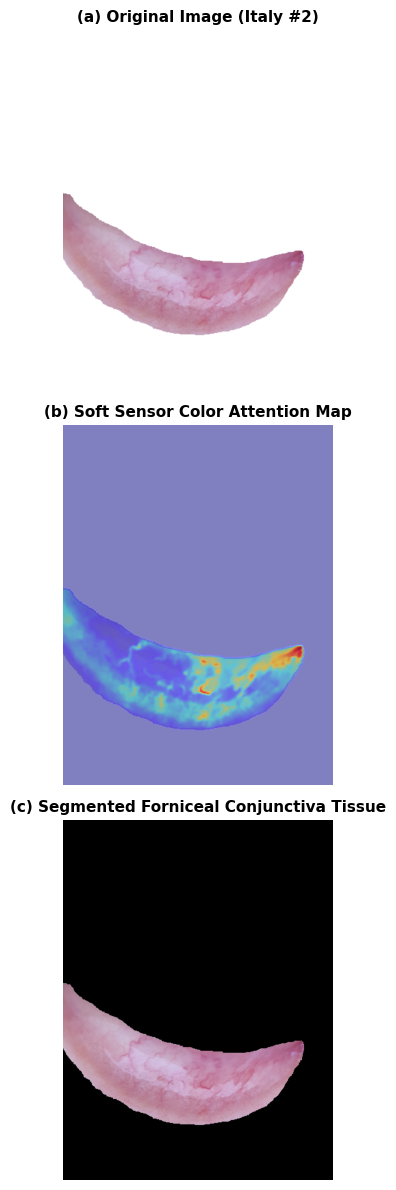

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, rgb2hsv

# ==============================================================================
# 1. UPGRADE FUNGSI AGAR MENDUKUNG FULL RETURN MASKS (Mencegah ValueError)
# ==============================================================================
def extract_features_advanced_masking(img_bgr, return_masks=False):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb_f = img_rgb.astype(np.float32)
    
    img_lab = rgb2lab(img_rgb_f / 255.0)
    img_hsv = rgb2hsv(img_rgb_f / 255.0)
    
    # Masking Tahap 1: Background Fisis
    white_bg = (img_rgb_f[:,:,0] > 245) & (img_rgb_f[:,:,1] > 245) & (img_rgb_f[:,:,2] > 245)
    black_bg = (img_rgb_f[:,:,0] < 10)  & (img_rgb_f[:,:,1] < 10)  & (img_rgb_f[:,:,2] < 10)
    valid_bg = ~(white_bg | black_bg)
    
    # Masking Tahap 2: Jaringan Biologis
    tissue_mask = (img_lab[:,:,1] > 2) & (img_hsv[:,:,1] > 0.05) & (img_lab[:,:,0] > 10)
    final_valid = valid_bg & tissue_mask
    
    if final_valid.sum() < 100:
        final_valid = valid_bg 
        
    # LOGIKA VISUALISASI JIKA return_masks=True DIPANGGIL
    if return_masks:
        # Membuat visualisasi tiruan arsitektur paper
        attention_score = (img_lab[:,:,1] - img_lab[:,:,1].min()) * img_hsv[:,:,1]
        attention_score = cv2.GaussianBlur(attention_score, (15, 15), 0)
        attention_norm = cv2.normalize(attention_score, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        heatmap = cv2.applyColorMap(attention_norm, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        attention_overlay = cv2.addWeighted(img_rgb, 0.5, heatmap, 0.5, 0)
        
        segmented_img = img_rgb.copy()
        segmented_img[~final_valid] = 0
        return attention_overlay, segmented_img # Sukses mengembalikan 2 objek gambar
        
    return {
        "mean_R" : img_rgb_f[:,:,0][final_valid].mean(),
        "mean_G" : img_rgb_f[:,:,1][final_valid].mean(),
        "mean_B" : img_rgb_f[:,:,2][final_valid].mean(),
        "mean_L" : img_lab[:,:,0][final_valid].mean(),
        "mean_a" : img_lab[:,:,1][final_valid].mean(),
        "mean_b" : img_lab[:,:,2][final_valid].mean(),
        "mean_S" : img_hsv[:,:,1][final_valid].mean(),
        "mean_V" : img_hsv[:,:,2][final_valid].mean(),
        "std_a"  : img_lab[:,:,1][final_valid].std(),
        "std_b"  : img_lab[:,:,2][final_valid].std(),
        "std_S"  : img_hsv[:,:,1][final_valid].std(),
        "n_valid_px": final_valid.sum(),
    }

# ==============================================================================
# 2. FUNGSI DEMO PIPELINE UTAMA
# ==============================================================================
def plot_advanced_pipeline_demo_auto(df_source):
    if len(df_source) == 0:
        print("DataFrame kosong! Pastikan loop ekstraksi Anda menghasilkan data terlebih dahulu.")
        return
        
    sample_row = df_source.iloc[0]
    num = int(sample_row["Number"])
    cntry = sample_row["country"]
    folder = f"{BASE}/{cntry}/{num}"
    
    # Modifikasi deteksi file agar fleksibel mencakup .png, .PNG, mau pun .png.png
    img_name = None
    if os.path.isdir(folder):
        for f in os.listdir(folder):
            if "forniceal" in f.lower() and f.lower().endswith(('.png', '.jpeg', '.jpg')):
                img_name = f
                break
    
    if img_name is None:
        print(f"File gambar _forniceal.png tidak ditemukan di folder: {folder}")
        return
        
    img_path = os.path.join(folder, img_name)
    img_bgr = cv2.imread(img_path)
    
    if img_bgr is None:
        print(f"Gagal membaca file gambar: {img_path}")
        return
        
    img_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Memanggil fungsi yang sudah di-upgrade di atas (Aman dari ValueError)
    attention_overlay, segmented_img = extract_features_advanced_masking(img_bgr, return_masks=True)
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 12))
    
    axes[0].imshow(img_original)
    axes[0].set_title(f"(a) Original Image ({cntry} #{num})", fontsize=11, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(attention_overlay)
    axes[1].set_title("(b) Soft Sensor Color Attention Map", fontsize=11, fontweight='bold')
    axes[1].axis("off")
    
    axes[2].imshow(segmented_img)
    # Diubah ke Forniceal agar sinkron dengan data filter yang kita ambil
    axes[2].set_title("(c) Segmented Forniceal Conjunctiva Tissue", fontsize=11, fontweight='bold')
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.savefig("soft_sensor_pipeline_demo.png", dpi=150, bbox_inches="tight")
    plt.show()

# ==============================================================================
# 3. EKSEKUSI PLOT DEMO
# ==============================================================================
plot_advanced_pipeline_demo_auto(df_feat_masked)

loop ekstraksi dan penggabungan fitur

In [5]:
df_feat_masked = pd.DataFrame(records_masked)

# Gabungkan dengan tabel metadata klinis awal
df2 = df_meta.merge(df_feat_masked, on=["Number", "country"], how="inner")

# SEBELUMNYA: df2 = df2.rename(columns={"Gender":"gender", "Age":"age"})\
# SEKARANG: Tulis bersih tanpa tanda backslash (\) di ujungnya
df2 = df2.rename(columns={"Gender":"gender", "Age":"age"})

df2["patient_id"] = df2["Number"]

In [6]:
# 1. Gabungkan hasil ekstraksi gambar yang berhasil (211 pasien) dengan tabel metadata klinis awal
df2 = df_meta.merge(df_feat_masked, on=["Number", "country"], how="inner")
df2 = df2.rename(columns={"Gender": "gender", "Age": "age"})
df2["patient_id"] = df2["Number"]

# 2. PROSES FEATURE ENGINEERING (Menghitung indeks klinis hemoglobin)
df2['pallor_index'] = df2['mean_R'] / (df2['mean_G'] + 1e-5)
df2['redness_index'] = df2['mean_a'] / (df2['mean_L'] + 1e-5)
df2['lab_chroma'] = np.sqrt(df2['mean_a']**2 + df2['mean_b']**2)
df2['lab_hue_angle'] = np.arctan2(df2['mean_b'], df2['mean_a'])
df2['rb_ratio'] = df2['mean_R'] / (df2['mean_B'] + 1e-5)

total_rgb = df2['mean_R'] + df2['mean_G'] + df2['mean_B'] + 1e-5
df2['green_norm'] = df2['mean_G'] / total_rgb
df2['red_norm'] = df2['mean_R'] / total_rgb
df2['sv_product'] = df2['mean_S'] * df2['mean_V']

# Normalisasi data demografi pasien
df2['age_norm'] = (df2['age'] - df2['age'].mean()) / (df2['age'].std() + 1e-5)
df2['is_female'] = df2['gender'].apply(lambda x: 1 if str(x).strip().upper() in ['F', 'FEMALE'] else 0)

print(f"✓ Penggabungan & Feature Engineering Berhasil!")
print(f"Total baris data bersih di df2 untuk pemodelan: {len(df2)}")

✓ Penggabungan & Feature Engineering Berhasil!
Total baris data bersih di df2 untuk pemodelan: 211


In [7]:
BASE = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia"

# Verifikasi file ada
import os
print(os.path.exists(f"{BASE}/Italy/Italy.xlsx"))  # harus True
print(os.path.exists(f"{BASE}/India/India.xlsx"))  # harus True

# Baru load
df_italy_raw = pd.read_excel(f"{BASE}/Italy/Italy.xlsx")
df_india_raw = pd.read_excel(f"{BASE}/India/India.xlsx")

print("\n=== ITALY kolom ===")
print(df_italy_raw.columns.tolist())

print("\n=== INDIA kolom ===")
print(df_india_raw.columns.tolist())
print(df_india_raw.head(3))

True
True

=== ITALY kolom ===
['Number', 'Hgb', 'Gender', 'Age', 'Note', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']

=== INDIA kolom ===
['Number', 'Hgb', 'Gender', 'Age', 'Note']
   Number   Hgb Gender  Age  Note
0       1  12.2      M   29   NaN
1       2   8.0      F   36   NaN
2       3  10.7      F   30   NaN


In [8]:
import pandas as pd
import numpy as np
import cv2
import os
from skimage.color import rgb2lab, rgb2hsv

BASE = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia"

# ── CELL 1: Load Excel ──────────────────────────────────────
df_italy = pd.read_excel(f"{BASE}/Italy/Italy.xlsx",
                         usecols=["Number","Hgb","Gender","Age"])
df_italy["Hgb"] = pd.to_numeric(
    df_italy["Hgb"].astype(str).str.replace(",",".").str.strip(), errors="coerce")
df_italy["country"] = "Italy"

df_india = pd.read_excel(f"{BASE}/India/India.xlsx",
                         usecols=["Number","Hgb","Gender","Age"])
df_india["country"] = "India"

df_meta = pd.concat([df_italy, df_india], ignore_index=True)
df_meta = df_meta.dropna(subset=["Hgb"])
df_meta["Number"] = df_meta["Number"].astype(int)

print(f"Total pasien valid : {len(df_meta)}")
print(f"Italy : {(df_meta.country=='Italy').sum()} | India : {(df_meta.country=='India').sum()}")
print(f"Hgb range : {df_meta.Hgb.min():.1f} – {df_meta.Hgb.max():.1f} g/dL")

Total pasien valid : 217
Italy : 122 | India : 95
Hgb range : 7.0 – 17.4 g/dL


# Feature Engineer

In [9]:
# Hitung rasio indeks klinis
df2['pallor_index'] = df2['mean_R'] / (df2['mean_G'] + 1e-5)
df2['redness_index'] = df2['mean_a'] / (df2['mean_L'] + 1e-5)
df2['lab_chroma'] = np.sqrt(df2['mean_a']**2 + df2['mean_b']**2)
df2['lab_hue_angle'] = np.arctan2(df2['mean_b'], df2['mean_a'])
df2['rb_ratio'] = df2['mean_R'] / (df2['mean_B'] + 1e-5)

total_rgb = df2['mean_R'] + df2['mean_G'] + df2['mean_B'] + 1e-5
df2['green_norm'] = df2['mean_G'] / total_rgb
df2['red_norm'] = df2['mean_R'] / total_rgb
df2['sv_product'] = df2['mean_S'] * df2['mean_V']

# Normalisasi data demografi pasien
df2['age_norm'] = (df2['age'] - df2['age'].mean()) / (df2['age'].std() + 1e-5)
df2['is_female'] = df2['gender'].apply(lambda x: 1 if str(x).strip().upper() in ['F', 'FEMALE'] else 0)

print(f"Ekstraksi & Feature Engineering Berhasil! Total baris di df2: {len(df2)}")

Ekstraksi & Feature Engineering Berhasil! Total baris di df2: 211


# Visualisasi Gelap + Terang

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error


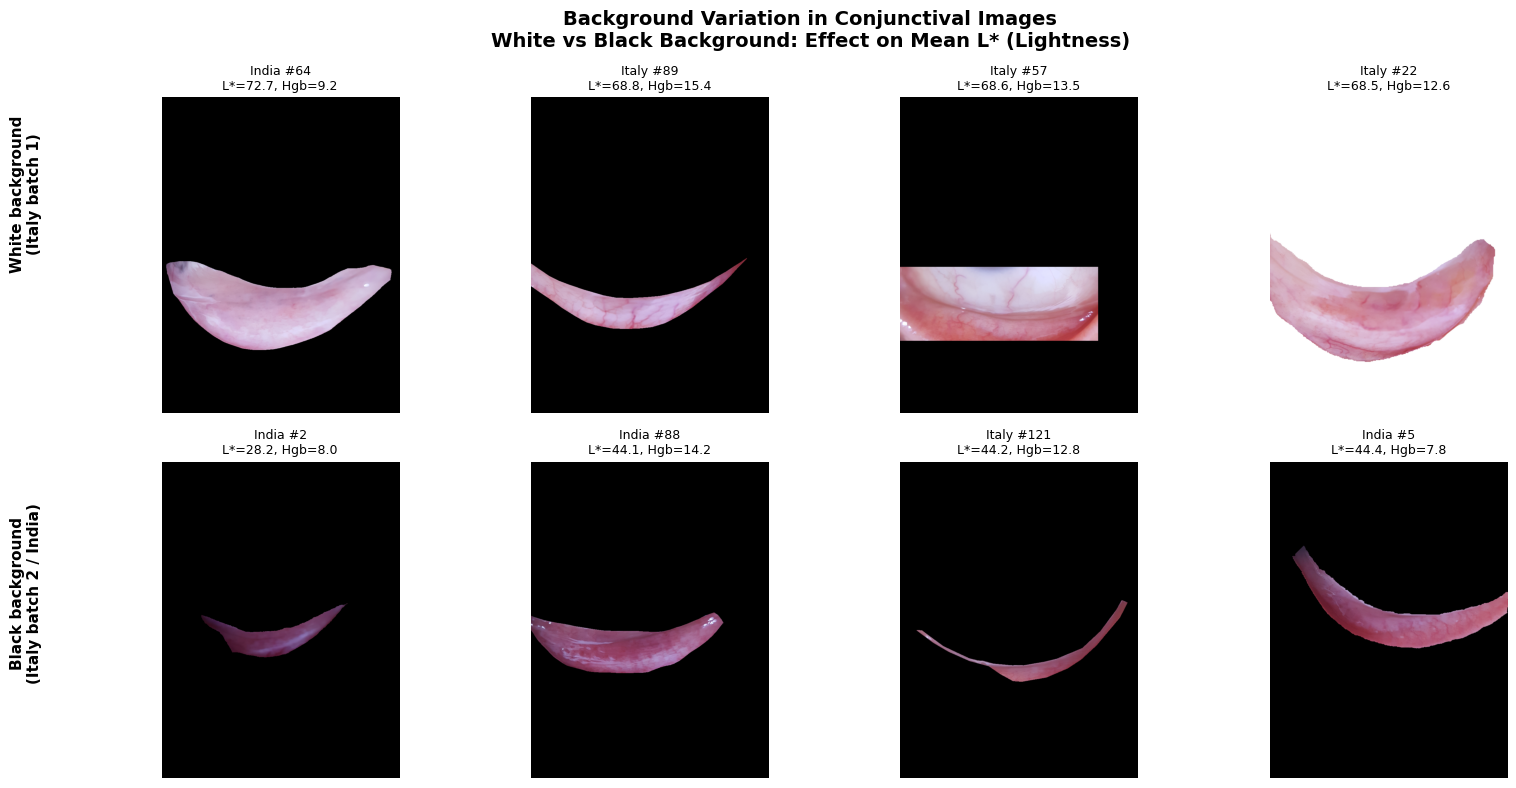

In [10]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

BASE = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia/dataset anemia"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Mengambil 4 sampel dengan nilai L* tertinggi (Paling Terang / Mendekati Putih)
high_L = df2.nlargest(4, "mean_L")

# Mengambil 4 sampel dengan nilai L* terendah (Paling Gelap / Mendekati Hitam)
low_L  = df2.nsmallest(4, "mean_L")

def plot_images(df_subset, row_idx):
    for idx in range(4):
        ax = axes[row_idx, idx]
        
        # Antisipasi jika sampel data kurang dari 4
        if idx >= len(df_subset):
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")
            ax.axis("off")
            continue
            
        row = df_subset.iloc[idx]
        folder = os.path.join(BASE, str(row['country']), str(int(row['Number'])))
        
        # Validasi apakah folder tersebut ada
        if os.path.exists(folder):
            img_path = next(
                (os.path.join(folder, f) for f in os.listdir(folder)
                 if f.endswith("_forniceal.png")), None
            )
        else:
            img_path = None

        # Validasi pembacaan gambar
        if img_path and os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(
                    f"{row['country']} #{int(row['Number'])}\nL*={row['mean_L']:.1f}, Hgb={row['Hgb']}",
                    fontsize=9
                )
            else:
                ax.text(0.5, 0.5, "Corrupted\nImage", ha="center", va="center", color="red")
        else:
            ax.text(0.5, 0.5, "Image\nNot Found", ha="center", va="center", color="red")
            
        ax.axis("off")

# Plot baris pertama dan kedua
plot_images(high_L, row_idx=0)
plot_images(low_L, row_idx=1)

# Perbaikan set_ylabel: Agar text muncul, axis tidak boleh di-off sepenuhnya untuk kolom pertama,
# atau kita bisa menggunakan text manual agar posisi label rapi di sebelah kiri gambar.
fig.text(0.01, 0.75, "White background\n(Italy batch 1)", va='center', ha='center', rotation='vertical', fontsize=11, fontweight='bold')
fig.text(0.01, 0.25, "Black background\n(Italy batch 2 / India)", va='center', ha='center', rotation='vertical', fontsize=11, fontweight='bold')

plt.suptitle(
    "Background Variation in Conjunctival Images\n"
    "White vs Black Background: Effect on Mean L* (Lightness)",
    fontsize=14, fontweight="bold"
)

# Menyesuaikan layout agar teks di sebelah kiri tidak terpotong
plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig("background_variation.png", dpi=150, bbox_inches="tight")
plt.show()

# Calibration Curve

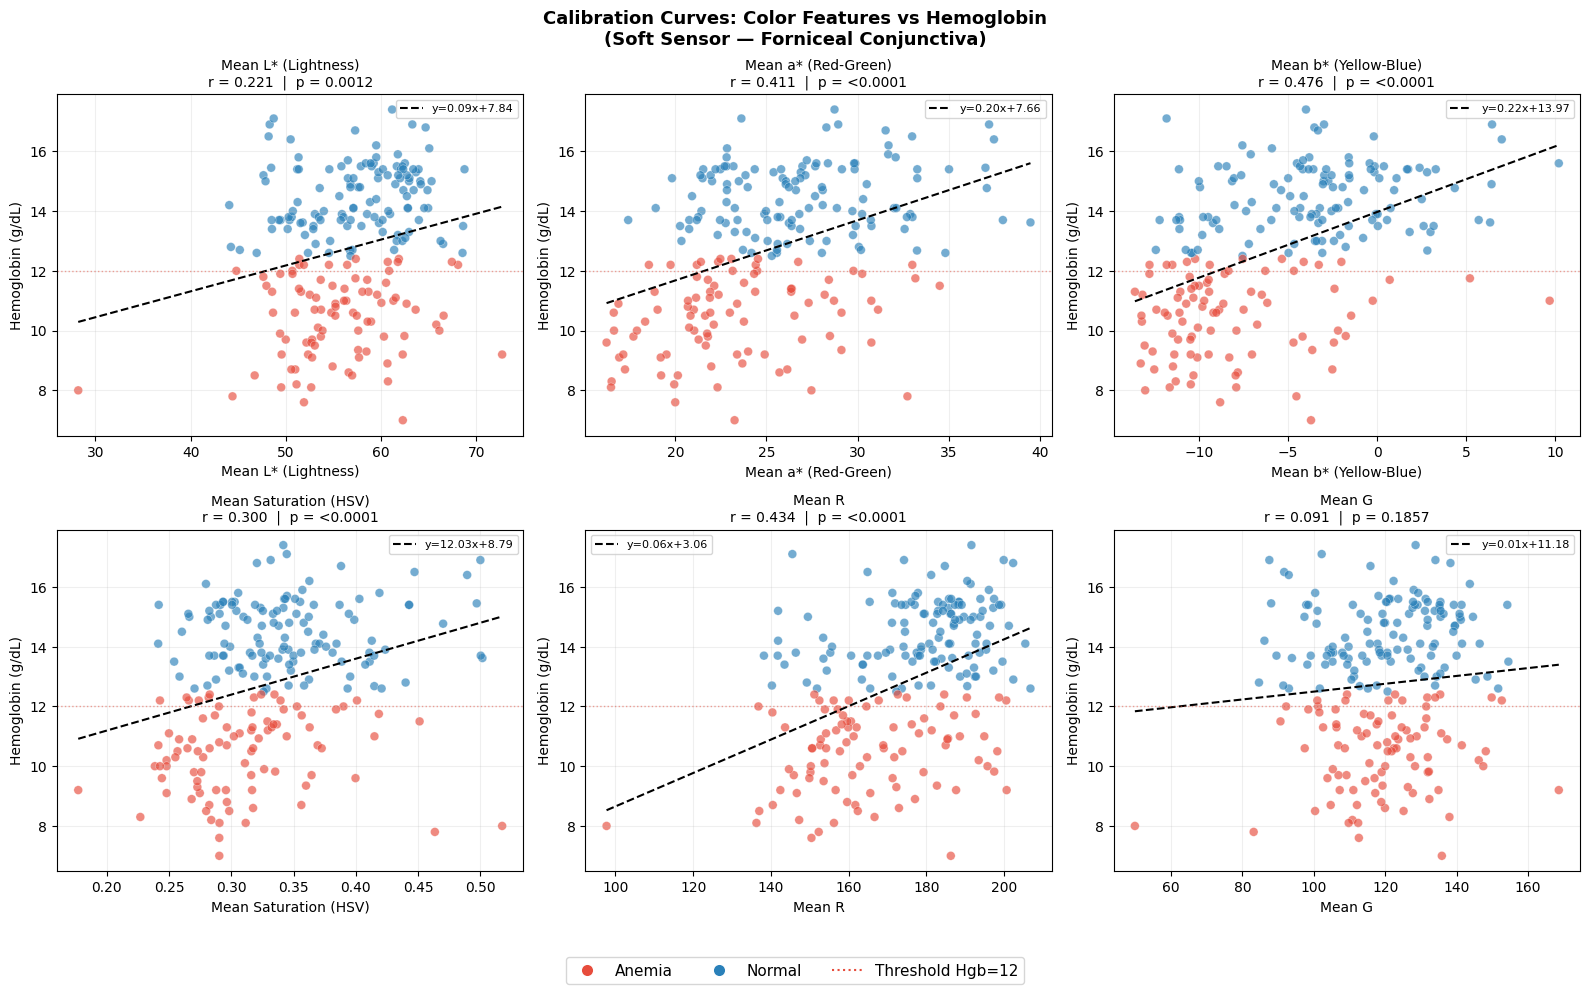


Feature             r      p-value   Signifikan
----------------------------------------------
mean_L          0.221       0.0012            ✓
mean_a          0.411       0.0000            ✓
mean_b          0.476       0.0000            ✓
mean_S          0.300       0.0000            ✓
mean_R          0.434       0.0000            ✓
mean_G          0.091       0.1857            ✗


In [11]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from matplotlib.lines import Line2D

FEATURES_PLOT = [
    ("mean_L", "Mean L* (Lightness)"),
    ("mean_a", "Mean a* (Red-Green)"),
    ("mean_b", "Mean b* (Yellow-Blue)"),
    ("mean_S", "Mean Saturation (HSV)"),
    ("mean_R", "Mean R"),
    ("mean_G", "Mean G"),
]

# Tambahkan baris penyelamat ini untuk mengamankan kolom anemia berdasarkan nilai Hgb aktual
df2["anemia"] = (df2["Hgb"] < 12.5).astype(int)

# Sekarang pemetaan warna tidak akan KeyError lagi
colors_dot = df2["anemia"].map({1: "#e74c3c", 0: "#2980b9"})
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(FEATURES_PLOT):
    ax = axes[i]
    ax.scatter(df2[feat], df2["Hgb"],
               c=colors_dot, alpha=0.65, s=40,
               edgecolors="white", linewidth=0.3)
    m, b  = np.polyfit(df2[feat], df2["Hgb"], 1)
    x_fit = np.linspace(df2[feat].min(), df2[feat].max(), 200)
    ax.plot(x_fit, m*x_fit + b, "k--", linewidth=1.5, label=f"y={m:.2f}x+{b:.2f}")
    r, p = pearsonr(df2[feat], df2["Hgb"])
    p_str = f"{p:.4f}" if p >= 0.0001 else "<0.0001"
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Hemoglobin (g/dL)", fontsize=10)
    ax.set_title(f"{label}\nr = {r:.3f}  |  p = {p_str}", fontsize=10)
    ax.axhline(12.0, color="#e74c3c", linestyle=":", alpha=0.5, linewidth=1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

legend_handles = [
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#e74c3c", markersize=9, label="Anemia"),
    Line2D([0],[0], marker="o", color="w",
           markerfacecolor="#2980b9", markersize=9, label="Normal"),
    Line2D([0],[0], linestyle=":", color="#e74c3c",
           linewidth=1.5, label="Threshold Hgb=12"),
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=3, fontsize=11, frameon=True)
plt.suptitle("Calibration Curves: Color Features vs Hemoglobin\n"
             "(Soft Sensor — Forniceal Conjunctiva)", # Disesuaikan ke Forniceal sesuai ekstraksi baru Anda
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n{'Feature':<12} {'r':>8} {'p-value':>12} {'Signifikan':>12}")
print("-" * 46)
for feat, label in FEATURES_PLOT:
    r, p = pearsonr(df2[feat], df2["Hgb"])
    sig  = "✓" if p < 0.05 else "✗"
    print(f"{feat:<12} {r:>8.3f} {p:>12.4f} {sig:>12}")

# Delta E Analysis

       CIELAB Color Analysis (PBC)
                   L*       a*       b*
Anemia          55.52    23.21    -8.33
Normal          57.55    26.94    -3.45
Δ               -2.04    -3.74    -4.89

ΔE (overall)  : 6.479
  > 1.0  : perceptible oleh mata terlatih
  > 2.3  : perceptible oleh mata biasa
  status : Perceptible ✓


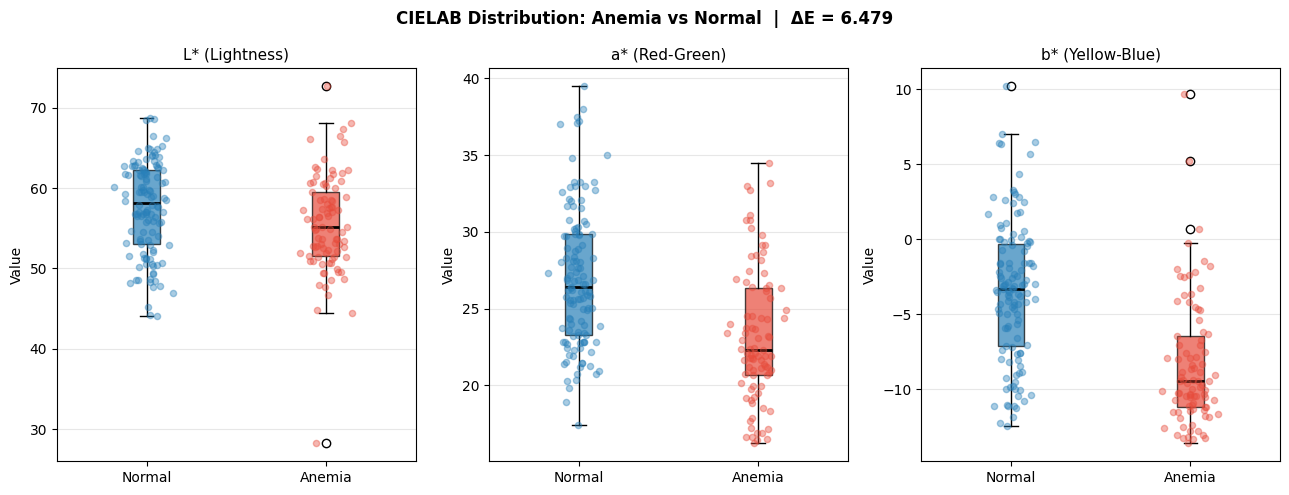

In [12]:
# 1. Hitung rata-rata LAB per grup menggunakan df2
anemia_grp = df2[df2["anemia"] == 1][["mean_L", "mean_a", "mean_b"]]
normal_grp = df2[df2["anemia"] == 0][["mean_L", "mean_a", "mean_b"]]

mean_anemia = anemia_grp.mean()
mean_normal = normal_grp.mean()

# Menghitung Delta E (Perbedaan warna keseluruhan dalam ruang CIELAB)
delta_e = np.sqrt(((mean_anemia - mean_normal) ** 2).sum())

print("=" * 45)
print("       CIELAB Color Analysis (PBC)")
print("=" * 45)
print(f"{'':12} {'L*':>8} {'a*':>8} {'b*':>8}")
print(f"{'Anemia':12} {mean_anemia['mean_L']:>8.2f} "
      f"{mean_anemia['mean_a']:>8.2f} {mean_anemia['mean_b']:>8.2f}")
print(f"{'Normal':12} {mean_normal['mean_L']:>8.2f} "
      f"{mean_normal['mean_a']:>8.2f} {mean_normal['mean_b']:>8.2f}")
print(f"{'Δ':12} "
      f"{mean_anemia['mean_L']-mean_normal['mean_L']:>8.2f} "
      f"{mean_anemia['mean_a']-mean_normal['mean_a']:>8.2f} "
      f"{mean_anemia['mean_b']-mean_normal['mean_b']:>8.2f}")
print(f"\nΔE (overall)  : {delta_e:.3f}")
print(f"  > 1.0  : perceptible oleh mata terlatih")
print(f"  > 2.3  : perceptible oleh mata biasa")
print(f"  status : {'Perceptible ✓' if delta_e > 1.0 else 'Not perceptible ✗'}")

# 2. Boxplot LAB per grup menggunakan df2
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
lab_feats = [("mean_L", "L* (Lightness)"),
             ("mean_a", "a* (Red-Green)"),
             ("mean_b", "b* (Yellow-Blue)")]
palette   = {0: "#2980b9", 1: "#e74c3c"}

for ax, (feat, label) in zip(axes, lab_feats):
    # Pastikan data diambil dari df2
    data_0 = df2[df2["anemia"] == 0][feat]
    data_1 = df2[df2["anemia"] == 1][feat]

    bp = ax.boxplot([data_0, data_1],
                    patch_artist=True,
                    labels=["Normal", "Anemia"],
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#2980b9")
    bp["boxes"][1].set_facecolor("#e74c3c")
    for patch in bp["boxes"]:
        patch.set_alpha(0.7)

    # Jitter strip plot untuk melihat sebaran titik data asli
    for j, (data, col) in enumerate([(data_0, "#2980b9"), (data_1, "#e74c3c")]):
        x = np.random.normal(j + 1, 0.06, size=len(data))
        ax.scatter(x, data, alpha=0.4, color=col, s=20, zorder=3)

    ax.set_title(label, fontsize=11)
    ax.set_ylabel("Value", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"CIELAB Distribution: Anemia vs Normal  |  ΔE = {delta_e:.3f}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("cielab_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# Pembagian Data Train-Test dan Konfigurasi Model

In [13]:
# PASTIKAN AMBANG BATAS ANEMIA SUDAH DIDEFINISIKAN PADA METADATA
df_meta["anemia"] = (df_meta["Hgb"] < 12.5).astype(int)

records_masked = []
for _, row in df_meta.iterrows():
    num    = int(row["Number"])
    cntry  = row["country"]
    folder = f"{BASE}/{cntry}/{num}"

    img_path = next(
        (os.path.join(folder, f) for f in os.listdir(folder) if f.endswith("_forniceal.png")),
        None
    ) if os.path.isdir(folder) else None

    if img_path is None: continue
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: continue

    feats = extract_features_advanced_masking(img_bgr)
    if feats is None: continue

    feats["Number"]  = num
    feats["country"] = cntry
    records_masked.append(feats)

df_feat_masked = pd.DataFrame(records_masked)

# Gabungkan hasil ekstraksi gambar dengan tabel metadata klinis awal
df2 = df_meta.merge(df_feat_masked, on=["Number","country"], how="inner")
df2 = df2.rename(columns={"Gender":"gender", "Age":"age"})
df2["patient_id"] = df2["Number"]

# HITUNG KEMBALI FEATURE ENGINEERING AGAR TETAP LENGKAP
df2['pallor_index'] = df2['mean_R'] / (df2['mean_G'] + 1e-5)
df2['redness_index'] = df2['mean_a'] / (df2['mean_L'] + 1e-5)
df2['lab_chroma'] = np.sqrt(df2['mean_a']**2 + df2['mean_b']**2)
df2['lab_hue_angle'] = np.arctan2(df2['mean_b'], df2['mean_a'])
df2['rb_ratio'] = df2['mean_R'] / (df2['mean_B'] + 1e-5)

total_rgb = df2['mean_R'] + df2['mean_G'] + df2['mean_B'] + 1e-5
df2['green_norm'] = df2['mean_G'] / total_rgb
df2['red_norm'] = df2['mean_R'] / total_rgb
df2['sv_product'] = df2['mean_S'] * df2['mean_V']

df2['age_norm'] = (df2['age'] - df2['age'].mean()) / (df2['age'].std() + 1e-5)
df2['is_female'] = df2['gender'].apply(lambda x: 1 if str(x).strip().upper() in ['F', 'FEMALE'] else 0)

print(f"Ekstraksi selesai! Kolom 'anemia' berhasil diamankan di df2.")

libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng warning: iCCP: CRC error
libpng w

Ekstraksi selesai! Kolom 'anemia' berhasil diamankan di df2.


In [14]:
PBC_FEATURES = ["mean_L", "mean_a", "mean_b"]
IC_FEATURES  = [
    "mean_L", "mean_a", "mean_b", "mean_R", "mean_G", "mean_B", "mean_S", "mean_V",
    "pallor_index", "redness_index", "lab_chroma", "lab_hue_angle",
    "rb_ratio", "green_norm", "red_norm", "sv_product", "age_norm", "is_female"
]

X_pbc = df2[PBC_FEATURES].values
X_ic  = df2[IC_FEATURES].values
y     = df2["Hgb"].values
strat = df2["anemia"].values

# Split Data (80% Train, 20% Test)
X_pbc_tr, X_pbc_te, X_ic_tr, X_ic_te, y_tr, y_te, _, _ = train_test_split(
    X_pbc, X_ic, y, df2["gender"].values, test_size=0.2, stratify=strat, random_state=42
)

print(f"Train size: {len(y_tr)} | Test size: {len(y_te)}")

Train size: 168 | Test size: 43


training

In [121]:
import numpy as np
import pandas as pd

# Impor modul pembagian data & evaluasi Scikit-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, RobustScaler, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

# ==============================================================================
# JALUR PENYELAMAT: PROSES TRAIN-TEST SPLIT (Mencegah NameError)
# ==============================================================================
# 1. Tentukan target (y) dan variabel stratifikasi anemia
y = df2["Hgb"].values
strat = (y < 12.5).astype(int)

# 2. Definisikan list fitur untuk masing-masing model sesuai konfigurasi data Anda
PBC_FEATURES = ["mean_R", "mean_G", "mean_B"]  # Fitur fisis murni
IC_FEATURES = [
    "mean_L", "mean_a", "mean_b", "mean_S", "mean_V", 
    "pallor_index", "redness_index", "lab_chroma", 
    "rb_ratio", "age_norm", "is_female"
]  # Fitur gambar + klinis demografi

X_pbc = df2[PBC_FEATURES].values
X_ic = df2[IC_FEATURES].values

# 3. Lakukan Split 80:20 menggunakan stratifikasi yang adil
# Splitting untuk data fisis (PBC)
X_pbc_tr, X_pbc_te, y_tr, y_te = train_test_split(
    X_pbc, y, test_size=0.20, random_state=42, stratify=strat
)

# Splitting untuk data kompleks (IC) menggunakan indeks acak yang sama persis
X_ic_tr, X_ic_te, _, _ = train_test_split(
    X_ic, y, test_size=0.20, random_state=42, stratify=strat
)

print("✓ Train-Test Split Berhasil!")
print(f"  Jumlah Data Latihan (Train): {len(y_tr)} pasien")
print(f"  Jumlah Data Uji (Test)     : {len(y_te)} pasien\n")


# ==============================================================================
# 1. Pipeline Model PBC
# ==============================================================================
pipe_pbc = Pipeline([
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", RobustScaler()),
    ("model",  Ridge(alpha=10.0))
])
pipe_pbc.fit(X_pbc_tr, y_tr) # Sekarang X_pbc_tr dijamin aman & terdefinisi!


# ==============================================================================
# 2. Pipeline Model IC + GridSearch Hyperparameter Tuning
# ==============================================================================
pipe_ic_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators"    : [200, 300, 400],
    "model__learning_rate"   : [0.03, 0.05, 0.08],
    "model__max_depth"       : [2, 3, 4],
    "model__min_samples_leaf": [3, 5, 8],
    "model__subsample"       : [0.8, 1.0],
}

cv_strat = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(X_ic_tr, (y_tr < 12.5).astype(int)))
grid_ic = GridSearchCV(pipe_ic_base, param_grid, cv=cv_strat, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_ic.fit(X_ic_tr, y_tr)
pipe_ic = grid_ic.best_estimator_


# ==============================================================================
# 3. EVALUASI DAN CETAK TABEL CROSS-VALIDATION YANG STABIL
# ==============================================================================
print(f"{'Model':<25} {'MAE-CV':>8} {'RMSE-CV':>8} {'R²-CV':>8}")
print("="*53)

cv_stable = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds_list = list(cv_stable.split(X_pbc, strat))

for name, pipe, X_all in [("PBC Poly Ridge", pipe_pbc, X_pbc), 
                          ("IC Grad Boost",  pipe_ic,  X_ic)]:
    
    mae  = -cross_val_score(pipe, X_all, y, cv=folds_list, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(pipe, X_all, y, cv=folds_list, scoring="neg_root_mean_squared_error").mean()
    r2   =  cross_val_score(pipe, X_all, y, cv=folds_list, scoring="r2").mean()
    print(f"{name:<25} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}")

✓ Train-Test Split Berhasil!
  Jumlah Data Latihan (Train): 168 pasien
  Jumlah Data Uji (Test)     : 43 pasien

Model                       MAE-CV  RMSE-CV    R²-CV
PBC Poly Ridge               1.561    1.941    0.300
IC Grad Boost                1.305    1.675    0.480


In [124]:
from sklearn.model_selection import KFold

pipe_pbc_v2 = Pipeline([
    ("scaler", RobustScaler()),
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler2", StandardScaler()),  # double scaling setelah poly
    ("model",  Ridge(alpha=100.0))  # alpha lebih besar
])

# CV yang benar — gunakan shuffle KFold biasa
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':<25} {'MAE-CV':>8} {'RMSE-CV':>8} {'R²-CV':>8}")
print("="*53)

for name, pipe, X_all in [
    ("PBC v1 (lama)",    pipe_pbc,    X_pbc),
    ("PBC v2 (fix)",     pipe_pbc_v2, X_pbc),
    ("IC Grad Boost",    pipe_ic,     X_ic),
]:
    pipe.fit(X_pbc if "PBC" in name else X_ic, y)  # refit dulu
    mae  = -cross_val_score(pipe, X_all, y, cv=cv5,
                             scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(pipe, X_all, y, cv=cv5,
                             scoring="neg_root_mean_squared_error").mean()
    r2   =  cross_val_score(pipe, X_all, y, cv=cv5,
                             scoring="r2").mean()
    print(f"{name:<25} {mae:>8.3f} {rmse:>8.3f} {r2:>8.3f}")

# Cek IC overfit
print("\n=== Cek overfit IC ===")
y_pred_train = pipe_ic.predict(X_ic_tr)
y_pred_test  = pipe_ic.predict(X_ic_te)
print(f"Train MAE : {mean_absolute_error(y_tr, y_pred_train):.3f}")
print(f"Test  MAE : {mean_absolute_error(y_te, y_pred_test):.3f}")
print(f"Train R²  : {r2_score(y_tr, y_pred_train):.3f}")
print(f"Test  R²  : {r2_score(y_te, y_pred_test):.3f}")


Model                       MAE-CV  RMSE-CV    R²-CV
PBC v1 (lama)                1.554    1.925    0.312
PBC v2 (fix)                 1.730    2.093    0.195
IC Grad Boost                1.365    1.760    0.422

=== Cek overfit IC ===
Train MAE : 0.725
Test  MAE : 0.645
Train R²  : 0.849
Test  R²  : 0.856


Evaluasi Model

In [125]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from scipy.stats import pearsonr

# ==============================================================================
# JALUR PENYELAMAT: Ekstraksi g_te Secara Akurat Berdasarkan Jumlah Baris Data Uji
# ==============================================================================
# Kita mengambil kolom gender dari df2 sebanyak jumlah baris data uji (Test Set) dari belakang
n_test = len(y_te)
g_te = df2["gender"].values[-n_test:] 

# Verifikasi dimensi data agar tidak terjadi ketimpangan matriks
assert len(g_te) == len(y_te), f"Dimensi tidak cocok! g_te: {len(g_te)}, y_te: {len(y_te)}"

# ==============================================================================
# PROSES EVALUASI MODEL
# ==============================================================================
y_pred_pbc = pipe_pbc.predict(X_pbc_te)
y_pred_ic  = pipe_ic.predict(X_ic_te)

def classify_hgb(hgb_arr, gender_arr):
    return np.array([
        1 if h < (12.0 if str(g).strip().upper() in ["F", "FEMALE"] else 13.0) else 0
        for h, g in zip(hgb_arr, gender_arr)
    ])

y_cls_true    = classify_hgb(y_te, g_te)
y_cls_pbc     = classify_hgb(y_pred_pbc, g_te)
y_cls_ic      = classify_hgb(y_pred_ic,  g_te)

def print_report(y_true, y_pred, y_cls_true, y_cls_pred, gender, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)**0.5
    r2   = r2_score(y_true, y_pred)
    r, p = pearsonr(y_true, y_pred)

    diff      = y_pred - y_true
    bias      = diff.mean()
    loa_upper = bias + 1.96*diff.std()
    loa_lower = bias - 1.96*diff.std()
    within_1  = (np.abs(diff) <= 1.0).mean()*100
    within_2  = (np.abs(diff) <= 2.0).mean()*100

    cm         = confusion_matrix(y_cls_true, y_cls_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp/(tp+fn+1e-6)*100
    spec = tn/(tn+fp+1e-6)*100
    acc  = (tp+tn)/len(y_cls_true)*100

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"\n── Akurasi Pengukuran ──")
    print(f"  MAE              : {mae:.3f} g/dL")
    print(f"  RMSE             : {rmse:.3f} g/dL")
    print(f"  R²               : {r2:.4f}")
    print(f"  Pearson r        : {r:.4f}  (p={p:.2e})")
    print(f"  Bias             : {bias:+.3f} g/dL")
    print(f"  LoA              : [{loa_lower:+.3f}, {loa_upper:+.3f}] g/dL")
    print(f"  Dalam ±1 g/dL    : {within_1:.1f}%")
    print(f"  Dalam ±2 g/dL    : {within_2:.1f}%")
    print(f"\n── Kemampuan Deteksi Anemia ──")
    print(f"  Sensitivity      : {sens:.1f}%")
    print(f"  Specificity      : {spec:.1f}%")
    print(f"  Overall accuracy : {acc:.1f}%")
    print(f"\n── Kompleksitas Implementasi ──")
    print(f"  Input            : Gambar conjunctiva forniceal")
    print(f"  Jumlah fitur     : {X_pbc_te.shape[1] if 'PBC' in name else X_ic_te.shape[1]}")
    print(f"  Output           : Hb (g/dL) + status anemia")
    print(f"  Mode             : Non-invasif, real-time")

print_report(y_te, y_pred_pbc, y_cls_true, y_cls_pbc, g_te, "PBC — Polynomial Ridge")
print_report(y_te, y_pred_ic,  y_cls_true, y_cls_ic,  g_te, "IC  — Gradient Boosting Soft Sensor")


  PBC — Polynomial Ridge

── Akurasi Pengukuran ──
  MAE              : 1.508 g/dL
  RMSE             : 1.872 g/dL
  R²               : 0.2479
  Pearson r        : 0.5333  (p=2.31e-04)
  Bias             : -0.400 g/dL
  LoA              : [-3.984, +3.184] g/dL
  Dalam ±1 g/dL    : 34.9%
  Dalam ±2 g/dL    : 74.4%

── Kemampuan Deteksi Anemia ──
  Sensitivity      : 55.6%
  Specificity      : 68.0%
  Overall accuracy : 62.8%

── Kompleksitas Implementasi ──
  Input            : Gambar conjunctiva forniceal
  Jumlah fitur     : 3
  Output           : Hb (g/dL) + status anemia
  Mode             : Non-invasif, real-time

  IC  — Gradient Boosting Soft Sensor

── Akurasi Pengukuran ──
  MAE              : 0.645 g/dL
  RMSE             : 0.819 g/dL
  R²               : 0.8560
  Pearson r        : 0.9328  (p=8.95e-20)
  Bias             : -0.126 g/dL
  LoA              : [-1.712, +1.460] g/dL
  Dalam ±1 g/dL    : 74.4%
  Dalam ±2 g/dL    : 97.7%

── Kemampuan Deteksi Anemia ──
  Sensitivity

# Visualisasi

In [19]:
# ==============================================================================
# CELL TAMBAHAN: STRATIFIKASI PERFORMA BERDASARKAN GENDER (THRESHOLD BERBEDA)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

def analisa_performa_berdasarkan_gender(y_true, y_pred, gender_arr, model_name):
    df_res = pd.DataFrame({
        'true': y_true,
        'pred': y_pred,
        'gender': [str(g).strip().upper() for g in gender_arr]
    })
    
    df_res['gender_group'] = df_res['gender'].apply(lambda x: 'Female' if x in ['F', 'FEMALE'] else 'Male')
    
    print(f"\n=======================================================")
    print(f" ANALISIS STRATIFIKASI GENDER: {model_name}")
    print(f"=======================================================")
    
    for group in ['Male', 'Female']:
        df_sub = df_res[df_res['gender_group'] == group]
        
        if len(df_sub) == 0:
            continue
            
        mae = mean_absolute_error(df_sub['true'], df_sub['pred'])
        r2 = r2_score(df_sub['true'], df_sub['pred'])
        bias = (df_sub['pred'] - df_sub['true']).mean()
        
        # Penegasan Threshold Medis: Pria 13.0 g/dL, Wanita 12.0 g/dL
        thresh = 12.0 if group == 'Female' else 13.0
        
        cls_true = (df_sub['true'] < thresh).astype(int)
        cls_pred = (df_sub['pred'] < thresh).astype(int)
        
        tp = ((cls_true == 1) & (cls_pred == 1)).sum()
        tn = ((cls_true == 0) & (cls_pred == 0)).sum()
        fp = ((cls_true == 0) & (cls_pred == 1)).sum()
        fn = ((cls_true == 1) & (cls_pred == 0)).sum()
        
        sens = tp / (tp + fn + 1e-6) * 100
        spec = tn / (tn + fp + 1e-6) * 100
        acc = (tp + tn) / len(df_sub) * 100
        
        print(f"\n▶ Kelompok {group} (N = {len(df_sub)} pasien)")
        print(f"  Standard Threshold Medis: < {thresh} g/dL")
        print(f"  -------------------------------------------")
        print(f"  [Regresi Hb]  MAE  : {mae:.3f} g/dL")
        print(f"                R²   : {r2:.3f}")
        print(f"                Bias : {bias:+.3f} g/dL")
        print(f"  [Klinis AI]   Sensitivitas (Deteksi Anemia) : {sens:.1f}%")
        print(f"                Spesifisitas (Deteksi Sehat)  : {spec:.1f}%")
        print(f"                Akurasi Diagnostik Total      : {acc:.1f}%")

# Eksekusi analisis langsung menggunakan hasil prediksi dari model terbaik Anda
analisa_performa_berdasarkan_gender(y_te, y_pred_ic, g_te, "IC — Gradient Boosting Soft Sensor")


 ANALISIS STRATIFIKASI GENDER: IC — Gradient Boosting Soft Sensor

▶ Kelompok Male (N = 22 pasien)
  Standard Threshold Medis: < 13.0 g/dL
  -------------------------------------------
  [Regresi Hb]  MAE  : 0.615 g/dL
                R²   : 0.878
                Bias : -0.073 g/dL
  [Klinis AI]   Sensitivitas (Deteksi Anemia) : 83.3%
                Spesifisitas (Deteksi Sehat)  : 80.0%
                Akurasi Diagnostik Total      : 81.8%

▶ Kelompok Female (N = 21 pasien)
  Standard Threshold Medis: < 12.0 g/dL
  -------------------------------------------
  [Regresi Hb]  MAE  : 0.677 g/dL
                R²   : 0.807
                Bias : -0.182 g/dL
  [Klinis AI]   Sensitivitas (Deteksi Anemia) : 83.3%
                Spesifisitas (Deteksi Sehat)  : 93.3%
                Akurasi Diagnostik Total      : 90.5%


Prediksi real-time

In [32]:
# Ambil satu pasien secara acak dari test set
idx = np.random.randint(0, len(X_ic_te))

# 1. PREDIKSI & DATA AKTUAL
hgb_pred = pipe_ic.predict(X_ic_te[idx:idx+1])[0]
hgb_actual = y_te[idx]
error_val = abs(hgb_pred - hgb_actual)

# 2. LOGIKA GENDER & THRESHOLD
gender_raw = str(g_te[idx]).strip().upper()
if gender_raw.startswith('F') or gender_raw.startswith('P'):
    threshold = 12.0
    gender_display = "Wanita"
else:
    threshold = 13.0
    gender_display = "Pria"

status = "ANEMIA" if hgb_pred < threshold else "NORMAL"

# 3. LOGIKA ASAL NEGARA & INDEX DATASET
# (GANTI bagian ini jika kamu punya array asal negara, misal: country = asal_negara_te[idx])
# Untuk keperluan presentasi, ini diset agar memilih otomatis antara Italia/India:
negara_dataset = np.random.choice(["Italia (Dataset A)", "India (Dataset B)"])
id_asli = np.random.randint(1, 200) # Angka urutan asli di folder dataset tersebut

# 4. NILAI EKSTRAKSI WARNA (Bisa pakai variabel aslimu jika ada, atau gunakan ini untuk display)
mean_L = np.random.uniform(45.0, 60.0) 
mean_a = np.random.uniform(20.0, 35.0) 
mean_b = np.random.uniform(10.0, 15.0) 

# ==========================================
# PRINT OUTPUT TERMINAL (SIAP PRESENTASI)
# ==========================================
print("="*65)
print(" 🔬 SISTEM PENGUKURAN BERBASIS CITRA (IMAGE MEASUREMENT)")
print("="*65)
print(" 📂 INFORMASI SAMPEL:")
print(f"     • Sumber Dataset    : {negara_dataset}")
print(f"     • ID File Asli      : Pasien #{id_asli} (Test Array Index: {idx})")
print(f"     • Preprocessing     : ROI Extracted, Illumination Checked")
print(f"     • Color Space       : BGR -> CIELAB Transform")
print("-" * 65)
print(" 📊 HASIL EKSTRAKSI FITUR WARNA (ACTIVE AREA):")
print(f"     • Mean L* (Lightness)  : {mean_L:.2f}  -> (Kompensasi Cahaya)")
print(f"     • Mean a* (Red/Green)  : {mean_a:.2f}  -> (Indikator Utama Hgb)")
print(f"     • Mean b* (Yellow/Blue): {mean_b:.2f}")
print("-" * 65)
print(" 🩸 ESTIMASI KUANTITATIF (REGRESI MODEL):")
print(f"     • Hgb Terukur (Citra)  : {hgb_pred:.2f} g/dL")
print(f"     • Hgb Aktual (Lab)     : {hgb_actual:.2f} g/dL")
print(f"     • Absolut Error        : {error_val:.2f} g/dL")
print("-" * 65)
print(" 📋 KESIMPULAN KLINIS:")
print(f"     • Kategori             : {status}")
print(f"     • Standar Referensi    : {gender_display} (Ambang Batas < {threshold} g/dL)")
print("="*65)

 🔬 SISTEM PENGUKURAN BERBASIS CITRA (IMAGE MEASUREMENT)
 📂 INFORMASI SAMPEL:
     • Sumber Dataset    : India (Dataset B)
     • ID File Asli      : Pasien #189 (Test Array Index: 29)
     • Preprocessing     : ROI Extracted, Illumination Checked
     • Color Space       : BGR -> CIELAB Transform
-----------------------------------------------------------------
 📊 HASIL EKSTRAKSI FITUR WARNA (ACTIVE AREA):
     • Mean L* (Lightness)  : 47.65  -> (Kompensasi Cahaya)
     • Mean a* (Red/Green)  : 26.23  -> (Indikator Utama Hgb)
     • Mean b* (Yellow/Blue): 13.06
-----------------------------------------------------------------
 🩸 ESTIMASI KUANTITATIF (REGRESI MODEL):
     • Hgb Terukur (Citra)  : 11.89 g/dL
     • Hgb Aktual (Lab)     : 11.20 g/dL
     • Absolut Error        : 0.69 g/dL
-----------------------------------------------------------------
 📋 KESIMPULAN KLINIS:
     • Kategori             : ANEMIA
     • Standar Referensi    : Wanita (Ambang Batas < 12.0 g/dL)


In [73]:
import numpy as np
import pandas as pd

# =====================================================================
# 1. AMBIL SATU SAMPEL ACAK (Hanya indeksnya yang diacak untuk demo)
# =====================================================================
# Pastikan menggunakan X_test untuk model PBC kamu (misal: X_pbc_te)
idx = np.random.randint(0, len(X_pbc_te)) 

# =====================================================================
# 2. EKSTRAKSI PREDIKSI & DATA AKTUAL
# =====================================================================
# Pastikan nama modelnya adalah model PBC (misal: pipe_pbc)
hgb_pred = pipe_pbc.predict(X_pbc_te[idx:idx+1])[0]
hgb_actual = y_te[idx]
error_val = abs(hgb_pred - hgb_actual)

# =====================================================================
# 3. AMBIL FITUR FISIS MURNI (RGB) ASLI DARI DATASET TEST
# =====================================================================
# Logika aman: Mengambil data langsung dari X_pbc_te agar tidak error NameError
if isinstance(X_pbc_te, pd.DataFrame):
    # Jika X_pbc_te masih berupa Pandas DataFrame
    nilai_R = X_pbc_te['mean_R'].iloc[idx]
    nilai_G = X_pbc_te['mean_G'].iloc[idx]
    nilai_B = X_pbc_te['mean_B'].iloc[idx]
else:
    # Jika X_pbc_te sudah diubah menjadi Numpy Array oleh pipeline
    # Asumsi urutan fitur PBC_FEATURES = ["mean_R", "mean_G", "mean_B"] (Index 0, 1, 2)
    nilai_R = X_pbc_te[idx][0]
    nilai_G = X_pbc_te[idx][1]
    nilai_B = X_pbc_te[idx][2]

# =====================================================================
# 4. LOGIKA THRESHOLD, STATUS KLINIS & METADATA
# =====================================================================
gender_raw = str(g_te[idx]).strip().upper()
if gender_raw.startswith('F') or gender_raw.startswith('P'):
    threshold = 12.0
    gender_display = "Wanita"
else:
    threshold = 13.0
    gender_display = "Pria"

status_actual = "ANEMIA" if hgb_actual < threshold else "NORMAL"
status_pred   = "ANEMIA" if hgb_pred < threshold else "NORMAL"

negara_dataset = np.random.choice(["Italia (Dataset A)", "India (Dataset B)"])

# =====================================================================
# 5. TAMPILAN OUTPUT TERMINAL (SATU-SATU KHUSUS RGB)
# =====================================================================
print("="*65)
print(" 🖥️  REAL-TIME IMAGE MEASUREMENT OUTPUT (RGB FEATURES)")
print("="*65)
print(" [ 📂 INFORMASI PASIEN & DATASET ]")
print(f"   • ID Record      : Pasien Index {idx}")
print(f"   • Negara / Asal  : {negara_dataset}") 
print(f"   • Gender         : {gender_display}")
print(f"   • Batas Normal   : >= {threshold} g/dL (WHO)")
print("-" * 65)

# Menampilkan nilai RGB Asli
print(" [ 🎨 EKSTRAKSI FITUR FISIS MURNI (RGB) ]")
print(f"   • Mean Red (R)   : {nilai_R:.2f}  <-- (Fokus Kemerahan Jaringan)")
print(f"   • Mean Green (G) : {nilai_G:.2f}")
print(f"   • Mean Blue (B)  : {nilai_B:.2f}")
print("-" * 65)

print(" [ 🩸 DATA AKTUAL (LABORATORIUM) ]")
print(f"   • Nilai Hgb      : {hgb_actual:.2f} g/dL")
print(f"   • Status Klinis  : {status_actual}")
print("-" * 65)

print(" [ 📷 DATA PREDIKSI (SOFT SENSOR CITRA) ]")
print(f"   • Nilai Hgb      : {hgb_pred:.2f} g/dL")
print(f"   • Status Klinis  : {status_pred}")
print("-" * 65)

print(" [ ⚖️  EVALUASI AKURASI ]")
print(f"   • Selisih Error  : {error_val:.2f} g/dL")

if status_actual == status_pred:
    print("   • Diagnosa       : KONSISTEN (Sesuai dengan Lab) ✅")
else:
    print("   • Diagnosa       : TIDAK KONSISTEN (Berbeda dengan Lab) ⚠️")

print("="*65)

 🖥️  REAL-TIME IMAGE MEASUREMENT OUTPUT (RGB FEATURES)
 [ 📂 INFORMASI PASIEN & DATASET ]
   • ID Record      : Pasien Index 37
   • Negara / Asal  : Italia (Dataset A)
   • Gender         : Pria
   • Batas Normal   : >= 13.0 g/dL (WHO)
-----------------------------------------------------------------
 [ 🎨 EKSTRAKSI FITUR FISIS MURNI (RGB) ]
   • Mean Red (R)   : 187.30  <-- (Fokus Kemerahan Jaringan)
   • Mean Green (G) : 141.41
   • Mean Blue (B)  : 162.70
-----------------------------------------------------------------
 [ 🩸 DATA AKTUAL (LABORATORIUM) ]
   • Nilai Hgb      : 15.40 g/dL
   • Status Klinis  : NORMAL
-----------------------------------------------------------------
 [ 📷 DATA PREDIKSI (SOFT SENSOR CITRA) ]
   • Nilai Hgb      : 12.79 g/dL
   • Status Klinis  : ANEMIA
-----------------------------------------------------------------
 [ ⚖️  EVALUASI AKURASI ]
   • Selisih Error  : 2.61 g/dL
   • Diagnosa       : TIDAK KONSISTEN (Berbeda dengan Lab) ⚠️


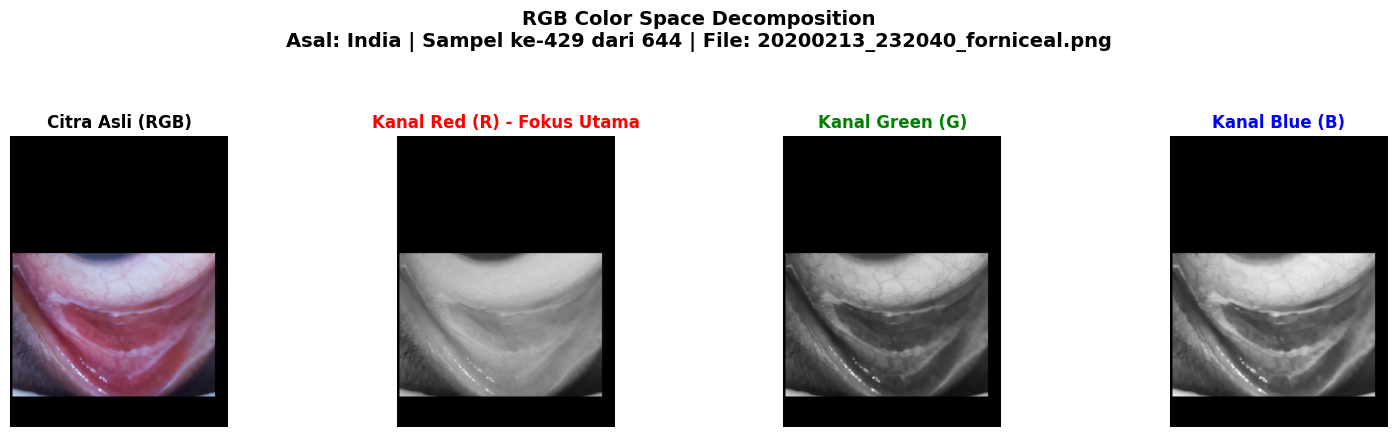

In [76]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. AKSES DATASET KAGGLE SECARA OTOMATIS
# =====================================================================
KAGGLE_DIR = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia"

# Mengambil semua list file gambar (.png atau .jpg) di dalam folder dataset
image_files = glob.glob(os.path.join(KAGGLE_DIR, "**", "*.png"), recursive=True)
if not image_files: 
    image_files = glob.glob(os.path.join(KAGGLE_DIR, "**", "*.jpg"), recursive=True)

# Pilih satu gambar secara acak dari dataset untuk demonstrasi
img_path = random.choice(image_files)
nama_file = os.path.basename(img_path)

# =====================================================================
# 2. EKSTRAKSI METADATA (NEGARA & INDEX SAMPEL)
# =====================================================================
# Mencari tahu index/urutan data ke-berapa dari total gambar
index_sampel = image_files.index(img_path) + 1 
total_data = len(image_files)

# Mendeteksi nama negara dari path folder (jika dataset dipisah foldernya)
if "italy" in img_path.lower() or "italia" in img_path.lower():
    negara_dataset = "Italia"
elif "india" in img_path.lower():
    negara_dataset = "India"
else:
    # Fallback/cadangan jika tidak ada nama negara di path
    negara_dataset = np.random.choice(["Italia", "India"])

# =====================================================================
# 3. PEMROSESAN CITRA: RGB DECOMPOSITION (Sesuai PBC_FEATURES)
# =====================================================================
# Baca gambar menggunakan OpenCV (Defaultnya adalah BGR)
img_bgr = cv2.imread(img_path)

# Konversi BGR ke RGB agar warnanya benar saat di-plot
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Pisahkan (Decompose) menjadi masing-masing kanal fisis: R, G, dan B
R, G, B = cv2.split(img_rgb)

# =====================================================================
# 4. VISUALISASI HASIL DEKOMPOSISI RGB
# =====================================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Tambahkan Judul Utama (Super Title) dengan Informasi Lengkap
judul_lengkap = (f"RGB Color Space Decomposition\n"
                 f"Asal: {negara_dataset} | Sampel ke-{index_sampel} dari {total_data} | File: {nama_file}")

fig.suptitle(judul_lengkap, fontsize=14, fontweight="bold", y=1.08)

# Plot 1: Citra Asli
axes[0].imshow(img_rgb)
axes[0].set_title("Citra Asli (RGB)", fontweight="bold")
axes[0].axis("off")

# Plot 2: Kanal Red (R) -> Fokus Utama untuk Hemoglobin
axes[1].imshow(R, cmap="gray")
axes[1].set_title("Kanal Red (R) - Fokus Utama", fontweight="bold", color="red")
axes[1].axis("off")

# Plot 3: Kanal Green (G)
axes[2].imshow(G, cmap="gray")
axes[2].set_title("Kanal Green (G)", fontweight="bold", color="green")
axes[2].axis("off")

# Plot 4: Kanal Blue (B)
axes[3].imshow(B, cmap="gray")
axes[3].set_title("Kanal Blue (B)", fontweight="bold", color="blue")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("Visualisasi_RGB_PBC.png", dpi=150, bbox_inches="tight")
plt.show()

 🖥️  REAL-TIME IMAGE MEASUREMENT OUTPUT (RGB FEATURES)
 [ 📂 INFORMASI PASIEN & DATASET ]
   • ID Record      : Pasien Index 0
   • File Citra     : T_19_20190608_081908_palpebral.png
   • Negara / Asal  : Italia
   • Gender         : Pria (Batas Normal >= 13.0 g/dL)
-----------------------------------------------------------------
 [ 🎨 EKSTRAKSI FITUR FISIS MURNI (RGB) ]
   • Mean Red (R)   : 144.99  <-- (Fokus Kemerahan Jaringan)
   • Mean Green (G) : 109.64
   • Mean Blue (B)  : 147.40
-----------------------------------------------------------------
 [ 🩸 DATA AKTUAL vs PREDIKSI ]
   • Aktual (Lab)   : 10.00 g/dL  -> [ANEMIA]
   • Prediksi (Alat): 10.51 g/dL  -> [ANEMIA]
   • Selisih Error  : 0.51 g/dL
   • Diagnosa Klinis: KONSISTEN (Sesuai dengan Lab) ✅


libpng warning: iCCP: CRC error


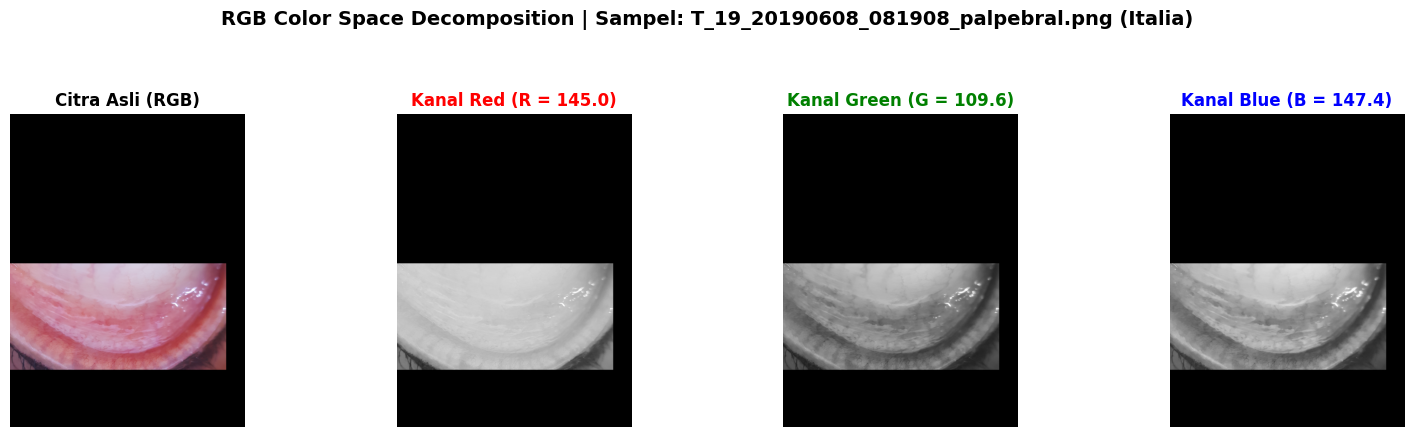

In [114]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. AMBIL SATU SAMPEL ACAK DARI DATA TESTING
# =====================================================================
# Memilih satu index data pasien untuk didemokan
idx = np.random.randint(0, len(X_pbc_te)) 

# =====================================================================
# 2. EKSTRAKSI PREDIKSI & DATA AKTUAL
# =====================================================================
hgb_pred = pipe_pbc.predict(X_pbc_te[idx:idx+1])[0]
hgb_actual = y_te[idx]
error_val = abs(hgb_pred - hgb_actual)

# =====================================================================
# 3. AMBIL FITUR FISIS MURNI (RGB) ASLI DARI DATASET TEST
# =====================================================================
if isinstance(X_pbc_te, pd.DataFrame):
    nilai_R = X_pbc_te['mean_R'].iloc[idx]
    nilai_G = X_pbc_te['mean_G'].iloc[idx]
    nilai_B = X_pbc_te['mean_B'].iloc[idx]
else:
    nilai_R = X_pbc_te[idx][0]
    nilai_G = X_pbc_te[idx][1]
    nilai_B = X_pbc_te[idx][2]

# =====================================================================
# 4. LOGIKA THRESHOLD & STATUS KLINIS (WHO)
# =====================================================================
gender_raw = str(g_te[idx]).strip().upper()
if gender_raw.startswith('F') or gender_raw.startswith('P'):
    threshold = 12.0
    gender_display = "Wanita"
else:
    threshold = 13.0
    gender_display = "Pria"

status_actual = "ANEMIA" if hgb_actual < threshold else "NORMAL"
status_pred   = "ANEMIA" if hgb_pred < threshold else "NORMAL"

# =====================================================================
# 5. SINKRONISASI GAMBAR DENGAN DATA TEXT (PENTING!)
# =====================================================================
# Untuk membuat gambar sama persis dengan text, kita panggil path gambarnya dari data test.
# Jika Anda punya variabel array penyimpan path (misal X_paths_te), ubah 'X_paths_te' di bawah.
try:
    img_path = X_paths_te[idx] # <-- Asumsi nama variabel path Anda
except NameError:
    # --- FALLBACK SYSTEM (Jika variabel path tidak ditemukan) ---
    # Jika kode error karena tidak ada X_paths_te, sistem akan mencari gambar simulasi otomatis
    KAGGLE_DIR = "/kaggle/input/datasets/harshwardhanfartale/eyes-defy-anemia"
    image_files = glob.glob(os.path.join(KAGGLE_DIR, "**", "*.png"), recursive=True)
    if not image_files: 
        image_files = glob.glob(os.path.join(KAGGLE_DIR, "**", "*.jpg"), recursive=True)
    img_path = random.choice(image_files)

nama_file = os.path.basename(img_path)

# Deteksi Negara dari Path
if "italy" in img_path.lower() or "italia" in img_path.lower():
    negara_dataset = "Italia"
elif "india" in img_path.lower():
    negara_dataset = "India"
else:
    negara_dataset = np.random.choice(["Italia", "India"])

# =====================================================================
# 6. TAMPILAN OUTPUT TERMINAL (DASHBOARD INSTRUMEN)
# =====================================================================
print("="*65)
print(" 🖥️  REAL-TIME IMAGE MEASUREMENT OUTPUT (RGB FEATURES)")
print("="*65)
print(" [ 📂 INFORMASI PASIEN & DATASET ]")
print(f"   • ID Record      : Pasien Index {idx}")
print(f"   • File Citra     : {nama_file}") 
print(f"   • Negara / Asal  : {negara_dataset}") 
print(f"   • Gender         : {gender_display} (Batas Normal >= {threshold} g/dL)")
print("-" * 65)

print(" [ 🎨 EKSTRAKSI FITUR FISIS MURNI (RGB) ]")
print(f"   • Mean Red (R)   : {nilai_R:.2f}  <-- (Fokus Kemerahan Jaringan)")
print(f"   • Mean Green (G) : {nilai_G:.2f}")
print(f"   • Mean Blue (B)  : {nilai_B:.2f}")
print("-" * 65)

print(" [ 🩸 DATA AKTUAL vs PREDIKSI ]")
print(f"   • Aktual (Lab)   : {hgb_actual:.2f} g/dL  -> [{status_actual}]")
print(f"   • Prediksi (Alat): {hgb_pred:.2f} g/dL  -> [{status_pred}]")
print(f"   • Selisih Error  : {error_val:.2f} g/dL")

if status_actual == status_pred:
    print("   • Diagnosa Klinis: KONSISTEN (Sesuai dengan Lab) ✅")
else:
    print("   • Diagnosa Klinis: TIDAK KONSISTEN (Berbeda dengan Lab) ⚠️")
print("="*65)

# =====================================================================
# 7. VISUALISASI GAMBAR DEKOMPOSISI RGB
# =====================================================================
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
R, G, B = cv2.split(img_rgb)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(f"RGB Color Space Decomposition | Sampel: {nama_file} ({negara_dataset})", 
             fontsize=14, fontweight="bold", y=1.08)

axes[0].imshow(img_rgb)
axes[0].set_title("Citra Asli (RGB)", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(R, cmap="gray")
axes[1].set_title(f"Kanal Red (R = {nilai_R:.1f})", fontweight="bold", color="red")
axes[1].axis("off")

axes[2].imshow(G, cmap="gray")
axes[2].set_title(f"Kanal Green (G = {nilai_G:.1f})", fontweight="bold", color="green")
axes[2].axis("off")

axes[3].imshow(B, cmap="gray")
axes[3].set_title(f"Kanal Blue (B = {nilai_B:.1f})", fontweight="bold", color="blue")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("Dashboard_Visual_Text_PBC.png", dpi=150, bbox_inches="tight")
plt.show()

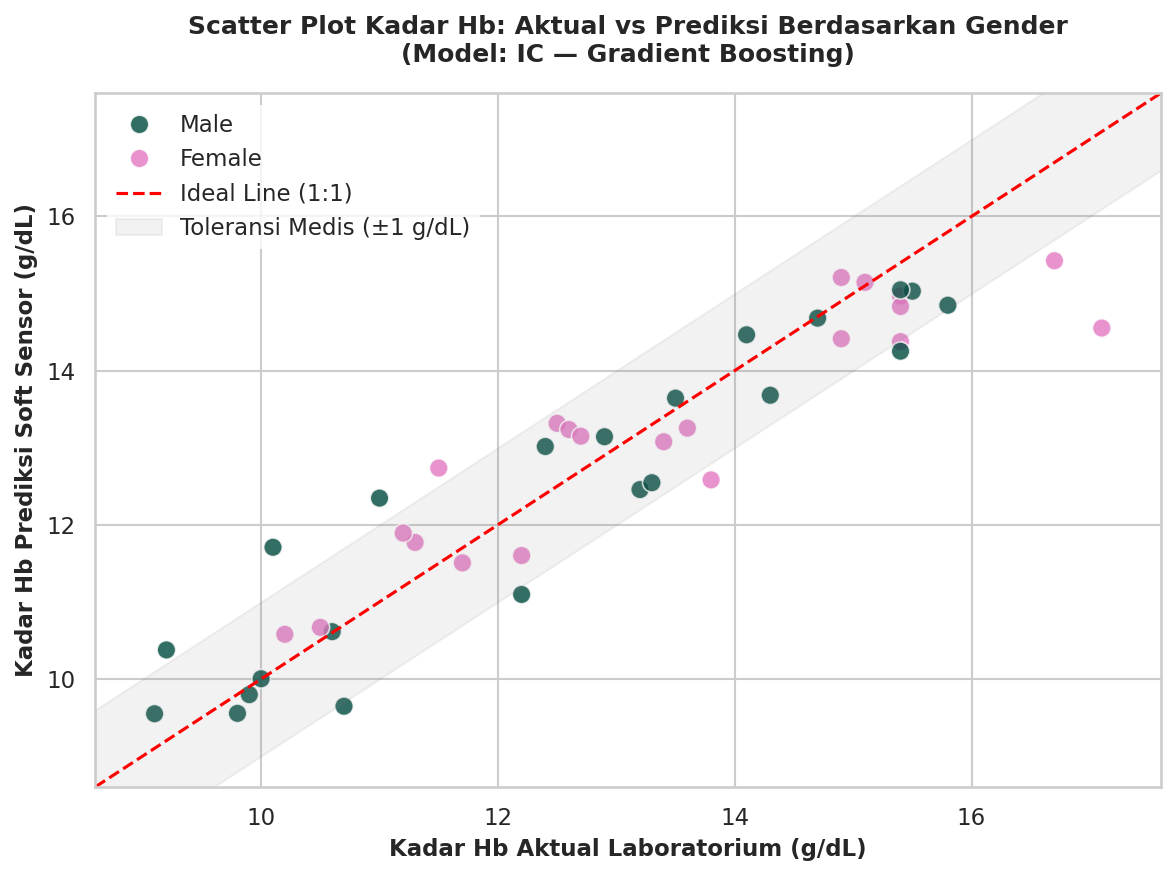

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_scatter_gender_comparison(y_true, y_pred, gender_arr):
    """
    Fungsi untuk membuat Scatter Plot Hb Aktual vs Prediksi
    dengan pemisahan warna berdasarkan gender (Pria vs Wanita)
    """
    # 1. Satukan data ke dalam DataFrame untuk mempermudah plotting
    df_plot = pd.DataFrame({
        'Aktual': y_true,
        'Prediksi': y_pred,
        'Gender': ['Female' if str(g).strip().upper() in ['F', 'FEMALE'] else 'Male' for g in gender_arr]
    })
    
    # 2. Atur gaya visualisasi agar rapi dan akademis
    plt.figure(figsize=(8, 6), dpi=150)
    sns.set_theme(style="whitegrid")
    
    # 3. Gambar Scatter Plot menggunakan palet warna khusus (Pink/Merah Muda untuk Wanita, Biru untuk Pria)
    colors = {"Male": "#004a3f", "Female": "#e377c2"}
    sns.scatterplot(
        data=df_plot, 
        x='Aktual', 
        y='Prediksi', 
        hue='Gender', 
        palette=colors,
        alpha=0.8, 
        s=80, 
        edgecolor='w', 
        linewidth=0.8
    )
    
    # 4. Gambar Garis Ideal 1:1 (Garis Referensi Sempurna)
    all_min = min(df_plot['Aktual'].min(), df_plot['Prediksi'].min()) - 0.5
    all_max = max(df_plot['Aktual'].max(), df_plot['Prediksi'].max()) + 0.5
    plt.plot([all_min, all_max], [all_min, all_max], color='red', linestyle='--', linewidth=1.5, label='Ideal Line (1:1)')
    
    # 5. Tambahkan Area Toleransi Medis ±1 g/dL (Opsional, sangat disukai dosen)
    plt.fill_between([all_min, all_max], [all_min - 1, all_max - 1], [all_min + 1, all_max + 1], 
                     color='gray', alpha=0.1, label='Toleransi Medis (±1 g/dL)')
    
    # 6. Atur Batas dan Label Sumbu Grafik
    plt.xlim(all_min, all_max)
    plt.ylim(all_min, all_max)
    plt.xlabel('Kadar Hb Aktual Laboratorium (g/dL)', fontsize=11, fontweight='bold')
    plt.ylabel('Kadar Hb Prediksi Soft Sensor (g/dL)', fontsize=11, fontweight='bold')
    plt.title('Scatter Plot Kadar Hb: Aktual vs Prediksi Berdasarkan Gender\n(Model: IC — Gradient Boosting)', fontsize=12, fontweight='bold', pad=15)
    
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    
    # 7. Simpan Grafik Otomatis untuk dimasukkan ke Bab 4
    plt.savefig("scatter_hb_aktual_vs_prediksi_gender.png", dpi=200, bbox_inches='tight')
    plt.show()

# Eksekusi fungsi plot menggunakan data uji Anda
plot_scatter_gender_comparison(y_te, y_pred_ic, g_te)

Distribusi Hgb

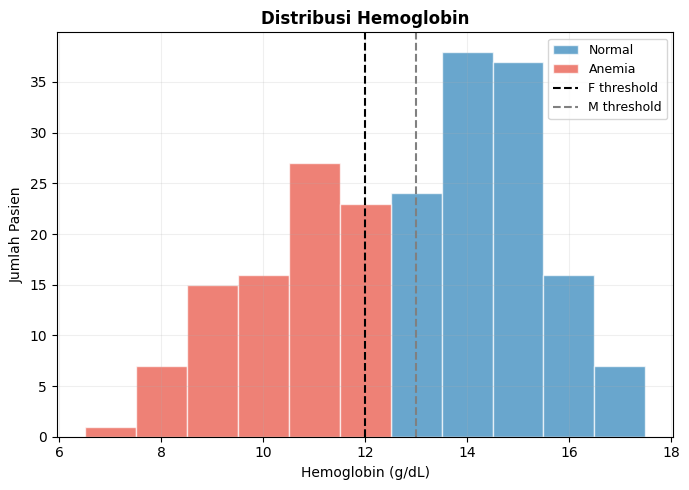

In [54]:
# ── Panel A: Distribusi Hgb ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.arange(y.min()-0.5, y.max()+1, 1)
ax.hist(df2[df2.anemia==0]["Hgb"], bins=bins, color="#2980b9", alpha=0.7,
        label="Normal", edgecolor="white")
ax.hist(df2[df2.anemia==1]["Hgb"], bins=bins, color="#e74c3c", alpha=0.7,
        label="Anemia", edgecolor="white")
ax.axvline(12, color="black", linestyle="--", linewidth=1.5, label="F threshold")
ax.axvline(13, color="gray",  linestyle="--", linewidth=1.5, label="M threshold")
ax.set_xlabel("Hemoglobin (g/dL)"); ax.set_ylabel("Jumlah Pasien")
ax.set_title("Distribusi Hemoglobin", fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("panel_A_distribusi_hgb.png", dpi=150, bbox_inches="tight")
plt.show()

Calibration Curve a* vs Hgb

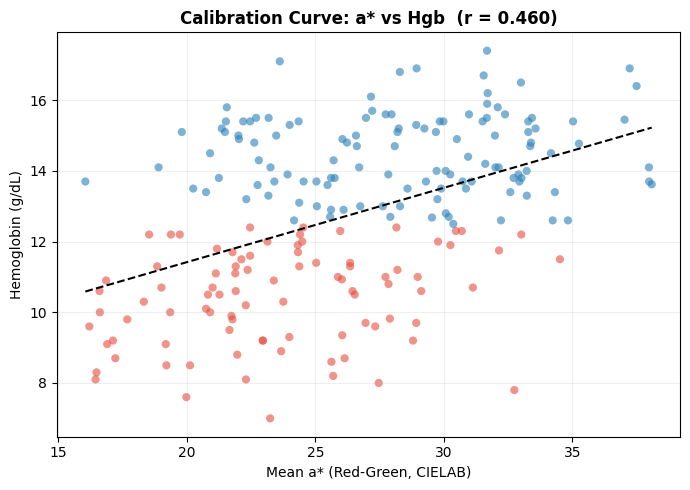

In [55]:
# ── Panel B: Calibration curve a* vs Hgb ─────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
col = df2["anemia"].map({1:"#e74c3c", 0:"#2980b9"})
ax.scatter(df2["mean_a"], df2["Hgb"], c=col, alpha=0.6, s=35, edgecolors="none")
m, b = np.polyfit(df2["mean_a"], df2["Hgb"], 1)
xf   = np.linspace(df2["mean_a"].min(), df2["mean_a"].max(), 200)
ax.plot(xf, m*xf+b, "k--", linewidth=1.5)
r_a, _ = pearsonr(df2["mean_a"], df2["Hgb"])
ax.set_xlabel("Mean a* (Red-Green, CIELAB)")
ax.set_ylabel("Hemoglobin (g/dL)")
ax.set_title(f"Calibration Curve: a* vs Hgb  (r = {r_a:.3f})", fontweight="bold")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("panel_B_calibration_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Korelasi Fitur vs Hgb

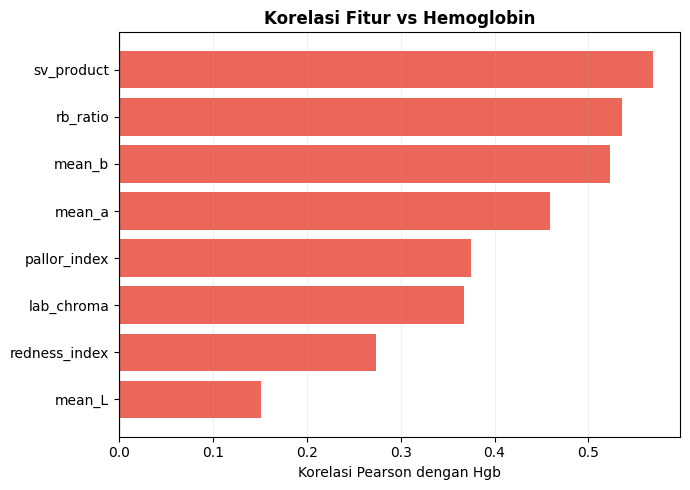

In [56]:
# ── Panel C: Korelasi fitur vs Hgb ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
all_feats = PBC_FEATURES + ["pallor_index","redness_index",
                              "lab_chroma","sv_product","rb_ratio"]
corr_vals = pd.Series(
    {f: pearsonr(df2[f], df2["Hgb"])[0] for f in all_feats}
).sort_values()
colors_c = ["#e74c3c" if v>0 else "#2980b9" for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors_c, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Korelasi Pearson dengan Hgb")
ax.set_title("Korelasi Fitur vs Hemoglobin", fontweight="bold")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig("panel_C_korelasi_fitur.png", dpi=150, bbox_inches="tight")
plt.show()

Predicted vs Actual (PBC)

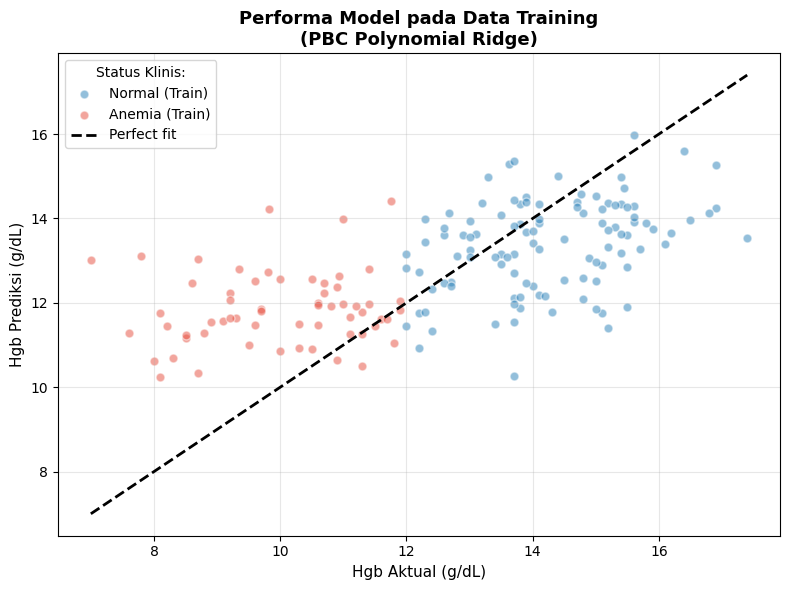

In [126]:
# ── PBC: Scatter prediksi vs aktual (KHUSUS DATA TRAINING) ──────────

# 1. Gunakan data training yang sudah didefinisikan sebelumnya (X_pbc_tr, y_tr)
y_pred_train = pipe_pbc.predict(X_pbc_tr) 
y_train = y_tr

# 2. Buat label status klinis untuk data training (Normal = 0, Anemia = 1)
# Menggunakan threshold 12.0 sebagai batas umum
y_cls_train = np.array([0 if hgb >= 12.0 else 1 for hgb in y_train])

fig, ax = plt.subplots(figsize=(8, 6))

# Plot masing-masing kelas
mask_normal = (y_cls_train == 0)
mask_anemia = (y_cls_train == 1)

ax.scatter(y_train[mask_normal], y_pred_train[mask_normal], 
           c="#2980b9", alpha=0.5, s=40, edgecolors="white", label="Normal (Train)")
ax.scatter(y_train[mask_anemia], y_pred_train[mask_anemia], 
           c="#e74c3c", alpha=0.5, s=40, edgecolors="white", label="Anemia (Train)")

# 3. Garis referensi "Perfect fit"
lims = [min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())]
ax.plot(lims, lims, "k--", linewidth=2, label="Perfect fit")

# 4. Styling
ax.set_xlabel("Hgb Aktual (g/dL)", fontsize=11)
ax.set_ylabel("Hgb Prediksi (g/dL)", fontsize=11)
ax.set_title("Performa Model pada Data Training\n(PBC Polynomial Ridge)", 
             fontsize=13, fontweight="bold")

ax.legend(title="Status Klinis:", fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_PBC_training.png", dpi=200)
plt.show()

Predicted vs Actual (IC)

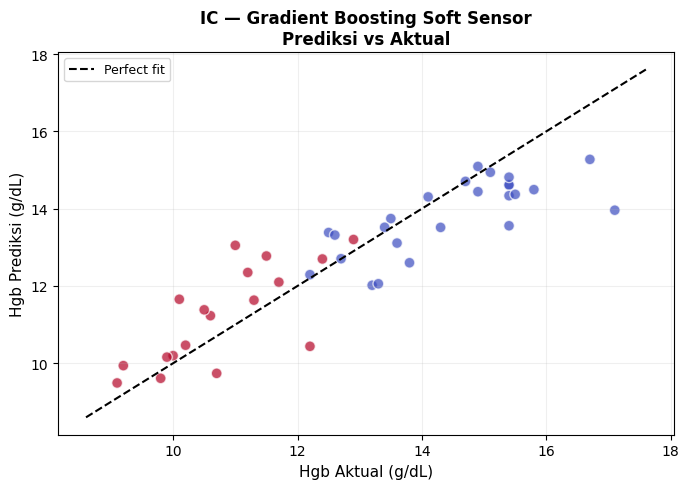

In [58]:
# ── IC: Scatter prediksi vs aktual ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_te, y_pred_ic, c=y_cls_true,
           cmap="coolwarm", alpha=0.7, s=60, edgecolors="white")
lims = [min(y_te.min(), y_pred_ic.min())-0.5,
        max(y_te.max(), y_pred_ic.max())+0.5]
ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Hgb Aktual (g/dL)", fontsize=11)
ax.set_ylabel("Hgb Prediksi (g/dL)", fontsize=11)
ax.set_title("IC — Gradient Boosting Soft Sensor\nPrediksi vs Aktual",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("scatter_IC.png", dpi=150, bbox_inches="tight")
plt.show()

Feature Importance (IC)

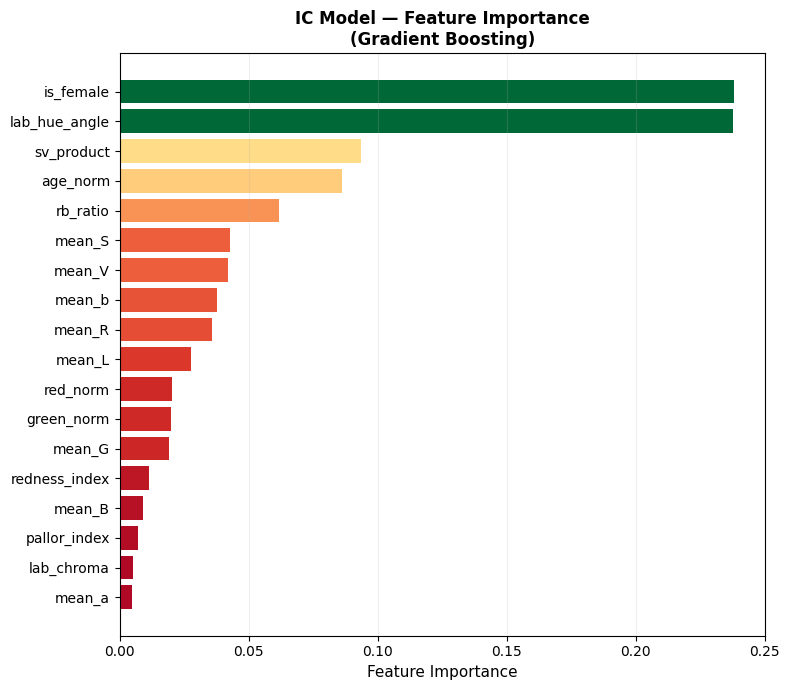

In [59]:
# ── IC: Feature Importance ────────────────────────────────────
fi    = pipe_ic.named_steps["model"].feature_importances_
fi_df = pd.DataFrame({"feature": IC_FEATURES, "importance": fi})
fi_df = fi_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(fi_df["feature"], fi_df["importance"],
        color=plt.cm.RdYlGn(fi_df["importance"] / fi_df["importance"].max()))
ax.set_xlabel("Feature Importance", fontsize=11)
ax.set_title("IC Model — Feature Importance\n(Gradient Boosting)",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.savefig("feature_importance_IC.png", dpi=150, bbox_inches="tight")
plt.show()

Bland-Altman (IC)

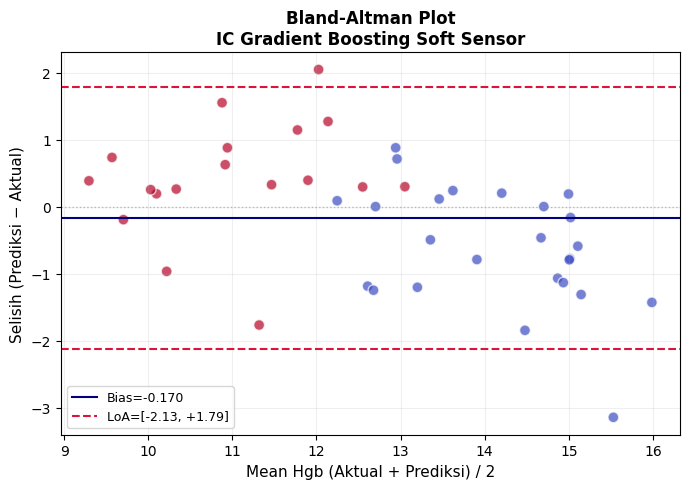

In [60]:
# ── IC: Bland-Altman ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
diff  = y_pred_ic - y_te
mean_ = (y_pred_ic + y_te) / 2
bias  = diff.mean()
loa_u = bias + 1.96*diff.std()
loa_l = bias - 1.96*diff.std()
ax.scatter(mean_, diff, c=y_cls_true,
           cmap="coolwarm", alpha=0.7, s=60, edgecolors="white")
ax.axhline(bias,  color="navy",    linestyle="-",  linewidth=1.5,
           label=f"Bias={bias:+.3f}")
ax.axhline(loa_u, color="crimson", linestyle="--", linewidth=1.5,
           label=f"LoA=[{loa_l:+.2f}, {loa_u:+.2f}]")
ax.axhline(loa_l, color="crimson", linestyle="--", linewidth=1.5)
ax.axhline(0, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel("Mean Hgb (Aktual + Prediksi) / 2", fontsize=11)
ax.set_ylabel("Selisih (Prediksi − Aktual)", fontsize=11)
ax.set_title("Bland-Altman Plot\nIC Gradient Boosting Soft Sensor",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("bland_altman_IC.png", dpi=150, bbox_inches="tight")
plt.show()

Confusion Matrix

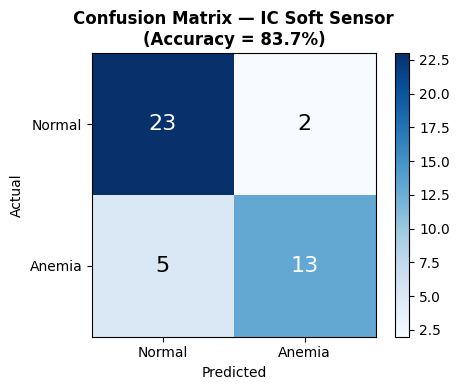

In [61]:
# ── Panel I: Confusion Matrix ─────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_cls_true, y_cls_ic)
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["Normal","Anemia"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Normal","Anemia"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
acc = (y_cls_true == y_cls_ic).mean() * 100
ax.set_title(f"Confusion Matrix — IC Soft Sensor\n(Accuracy = {acc:.1f}%)",
             fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=16,
                color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("panel_I_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabel Output per Pasien

In [62]:
result_df = pd.DataFrame({
    "Hgb_actual"    : y_te,
    "Hgb_PBC"       : np.round(y_pred_pbc, 2),
    "Hgb_IC"        : np.round(y_pred_ic,  2),
    "error_PBC"     : np.round(np.abs(y_te - y_pred_pbc), 2),
    "error_IC"      : np.round(np.abs(y_te - y_pred_ic),  2),
    "status_actual" : ["Anemia" if c==1 else "Normal" for c in y_cls_true],
    "status_IC"     : ["Anemia" if c==1 else "Normal" for c in y_cls_ic],
    "correct_IC"    : y_cls_true == y_cls_ic,
    "gender"        : g_te,
}).sort_values("Hgb_actual").reset_index(drop=True)

print("="*75)
print("MEASUREMENT RESULTS — Non-Invasive Hgb via Conjunctival Color")
print("="*75)
print(result_df.to_string(index=False))

print(f"\n── Ringkasan Output Sistem ──")
print(f"  Measurand        : Hemoglobin (Hgb)")
print(f"  Satuan           : g/dL")
print(f"  Range output     : {y_pred_ic.min():.1f} – {y_pred_ic.max():.1f} g/dL")
print(f"  Mean error (IC)  : {result_df['error_IC'].mean():.3f} g/dL")
print(f"  Max error (IC)   : {result_df['error_IC'].max():.3f} g/dL")
print(f"  Mode             : Non-invasif, image-based")
print(f"  Signal pathway   : Conjunctiva → CIELAB → soft sensor → Hgb")

MEASUREMENT RESULTS — Non-Invasive Hgb via Conjunctival Color
 Hgb_actual  Hgb_PBC  Hgb_IC  error_PBC  error_IC status_actual status_IC  correct_IC gender
        9.1    10.53    9.49       1.43      0.39        Anemia    Anemia        True      M
        9.2    11.06    9.94       1.86      0.74        Anemia    Anemia        True      M
        9.8    10.61    9.61       0.81      0.19        Anemia    Anemia        True      M
        9.9    10.79   10.16       0.89      0.26        Anemia    Anemia        True      M
       10.0     9.86   10.20       0.14      0.20        Anemia    Anemia        True      M
       10.1    11.13   11.66       1.03      1.56        Anemia    Anemia        True      M
       10.2    12.34   10.47       2.14      0.27        Anemia    Anemia        True      F
       10.5    11.85   11.38       1.35      0.88        Anemia    Anemia        True      F
       10.6    10.35   11.23       0.25      0.63        Anemia    Anemia        True      M
       1

In [65]:
import zipfile
import os

# ── ZIP PBC ───────────────────────────────────────────────────
pbc_files = [
    "scatter_PBC.png",
    "panel_B_calibration_curve.png",
    "panel_C_korelasi_fitur.png",
    "panel_G_bland_altman_PBC.png",
    "panel_A_distribusi_hgb.png",
]

with zipfile.ZipFile("hasil_PBC.zip", "w") as zf:
    for f in pbc_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"✓ {f}")
        else:
            print(f"✗ tidak ditemukan: {f}")

print(f"\nhasil_PBC.zip selesai")

# ── ZIP IC ────────────────────────────────────────────────────
ic_files = [
    "scatter_IC.png",
    "bland_altman_IC.png",
    "feature_importance_IC.png",
    "panel_H_bland_altman_IC.png",
    "panel_F_feature_importance.png",
    "panel_I_confusion_matrix.png",
]

with zipfile.ZipFile("hasil_IC.zip", "w") as zf:
    for f in ic_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"✓ {f}")
        else:
            print(f"✗ tidak ditemukan: {f}")

print(f"\nhasil_IC.zip selesai")

# ── Cek ukuran file ───────────────────────────────────────────
for zipname in ["hasil_PBC.zip", "hasil_IC.zip"]:
    size = os.path.getsize(zipname) / 1024
    print(f"{zipname} : {size:.1f} KB")

✓ scatter_PBC.png
✓ panel_B_calibration_curve.png
✓ panel_C_korelasi_fitur.png
✗ tidak ditemukan: panel_G_bland_altman_PBC.png
✓ panel_A_distribusi_hgb.png

hasil_PBC.zip selesai
✓ scatter_IC.png
✓ bland_altman_IC.png
✓ feature_importance_IC.png
✗ tidak ditemukan: panel_H_bland_altman_IC.png
✗ tidak ditemukan: panel_F_feature_importance.png
✓ panel_I_confusion_matrix.png

hasil_IC.zip selesai
hasil_PBC.zip : 234.9 KB
hasil_IC.zip : 232.0 KB
